# 🏦 Modelo de Colas M/M/s — Optimización de Servidores en Agencias Bancarias

**Herramienta:** Decisión de contratación de auxiliar de operaciones, análisis de tiempos de espera y servidores óptimos por franja horaria.

**Modelo:** M/M/s (Markov/Markov/s servidores) — llegadas Poisson, tiempos de servicio Exponenciales, s servidores en paralelo.

---
## Índice
1. [Configuración e Importaciones](#1)
2. [EDA — Análisis Exploratorio de Datos](#2)
3. [Cálculo de μ Ponderado por Franja Horaria](#3)
4. [Modelo M/M/s — Fórmulas Analíticas](#4)
5. [Optimización de Servidores](#5)
6. [Decisión: ¿Contratar Auxiliar?](#6)
7. [Simulación Monte Carlo con SimPy](#7)
8. [Análisis de Sensibilidad](#8)
9. [Exportación para Power BI](#9)

---
## 1. Configuración e Importaciones <a id='1'></a>

### ¿Qué importamos y por qué?
- **pandas / numpy**: manipulación de datos y cálculos vectorizados.
- **scipy.special**: función factorial y cálculos matemáticos avanzados.
- **matplotlib / seaborn**: visualizaciones estadísticas.
- **simpy**: librería de simulación de eventos discretos (Discrete Event Simulation).
- **warnings / itertools**: utilidades generales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import simpy
import warnings
import math
from scipy.special import factorial
from scipy.optimize import minimize_scalar
from itertools import product

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── Rutas de archivos ──────────────────────────────────────────────────────────
PATH_DF   = 'df.csv'
PATH_DIST = 'dist_agencias.csv'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 2. EDA — Análisis Exploratorio de Datos <a id='2'></a>

**Objetivo:** Entender la estructura, distribución y calidad de los datos antes de aplicar el modelo.

In [2]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
df   = pd.read_csv(PATH_DF)
dist = pd.read_csv(PATH_DIST)

# Normalizar nombres de columnas
df.columns   = df.columns.str.strip().str.lower()
dist.columns = dist.columns.str.strip()

print('─── df.csv ────────────────────────────────────')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
display(df.head(10))
print('\nTipos de datos:')
display(df.dtypes)

print('\n─── dist_agencias.csv ─────────────────────────')
print(f'Filas: {dist.shape[0]} | Columnas: {dist.shape[1]}')
display(dist)

─── df.csv ────────────────────────────────────
Filas: 20 | Columnas: 6


,agencia,hora,lambda,servidores,cs,cq
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,5,13.64,27.29
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,5,13.64,27.29
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,5,13.64,27.29
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,5,13.64,27.29
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,5,13.64,27.29
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,5,13.64,27.29
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,5,13.64,27.29
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,5,13.64,27.29
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,5,13.64,27.29
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,5,13.64,27.29



Tipos de datos:


agencia           str
hora              str
lambda        float64
servidores      int64
cs            float64
cq            float64
dtype: object


─── dist_agencias.csv ─────────────────────────
Filas: 12 | Columnas: 12


,agencia,tipo_ope,09:00:00 - 09:59:59,10:00:00 - 10:59:59,11:00:00 - 11:59:59,12:00:00 - 12:59:59,13:00:00 - 13:59:59,14:00:00 - 14:59:59,15:00:00 - 15:59:59,16:00:00 - 16:59:59,17:00:00 - 17:59:59,18:00:00 - 18:59:59
0,AG. CIUDAD UNIVERSITARIA,DEPOSITO,0.4180,0.4114,0.4165,0.4278,0.4257,0.4599,0.4308,0.3692,0.3058,0.2372
1,AG. CIUDAD UNIVERSITARIA,COBRANZA LOCALES OTRAS AGENCIAS,0.1506,0.1444,0.1497,0.1511,0.1673,0.1730,0.1785,0.1815,0.1784,0.1439
2,AG. CIUDAD UNIVERSITARIA,COBRANZAS,0.1048,0.1048,0.0972,0.0970,0.0979,0.0921,0.0957,0.1167,0.1391,0.1537
3,AG. CIUDAD UNIVERSITARIA,RETIRO,0.1809,0.1619,0.1583,0.1593,0.1902,0.1615,0.1546,0.1438,0.1265,0.1675
4,AG. CIUDAD UNIVERSITARIA,DESEMBOLSO,0.0296,0.0350,0.0374,0.0431,0.0473,0.0403,0.0341,0.0413,0.0684,0.1150
5,AG. CIUDAD UNIVERSITARIA,APERTURA,0.0388,0.0372,0.0439,0.0446,0.0497,0.0504,0.0428,0.0431,0.0362,0.0727
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,DEPOSITO,0.3560,0.3570,0.3569,0.3581,0.3474,0.3670,0.3881,0.3595,0.3048,0.2337
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZA LOCALES OTRAS AGENCIAS,0.1771,0.1618,0.1615,0.1729,0.1873,0.2064,0.1898,0.1880,0.1877,0.1572
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,COBRANZAS,0.2339,0.2097,0.2002,0.1973,0.2685,0.2180,0.1925,0.1749,0.1602,0.2248
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,RETIRO,0.0941,0.0952,0.0995,0.0970,0.0924,0.0875,0.0875,0.1053,0.1253,0.1588


In [3]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────────
print('=== Estadísticas descriptivas — df.csv ===')
display(df.describe().round(3))

=== Estadísticas descriptivas — df.csv ===


,lambda,servidores,cs,cq
count,20.000,20.000,20.000,20.000
mean,48.573,5.500,13.180,26.365
std,14.131,0.513,0.472,0.949
min,23.450,5.000,12.720,25.440
25%,36.275,5.000,12.720,25.440
50%,48.470,5.500,13.180,26.365
75%,60.275,6.000,13.640,27.290
max,67.830,6.000,13.640,27.290


In [6]:
# ── Verificación de nulos ──────────────────────────────────────────────────────
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Valores nulos — distribución:')
print(dist.isnull().sum())

Valores nulos por columna:
agencia       0
hora          0
lambda        0
servidores    0
cs            0
cq            0
dtype: int64

Valores nulos — distribución:
agencia                0
tipo_ope               0
09:00:00 - 09:59:59    0
10:00:00 - 10:59:59    0
11:00:00 - 11:59:59    0
12:00:00 - 12:59:59    0
13:00:00 - 13:59:59    0
14:00:00 - 14:59:59    0
15:00:00 - 15:59:59    0
16:00:00 - 16:59:59    0
17:00:00 - 17:59:59    0
18:00:00 - 18:59:59    0
dtype: int64


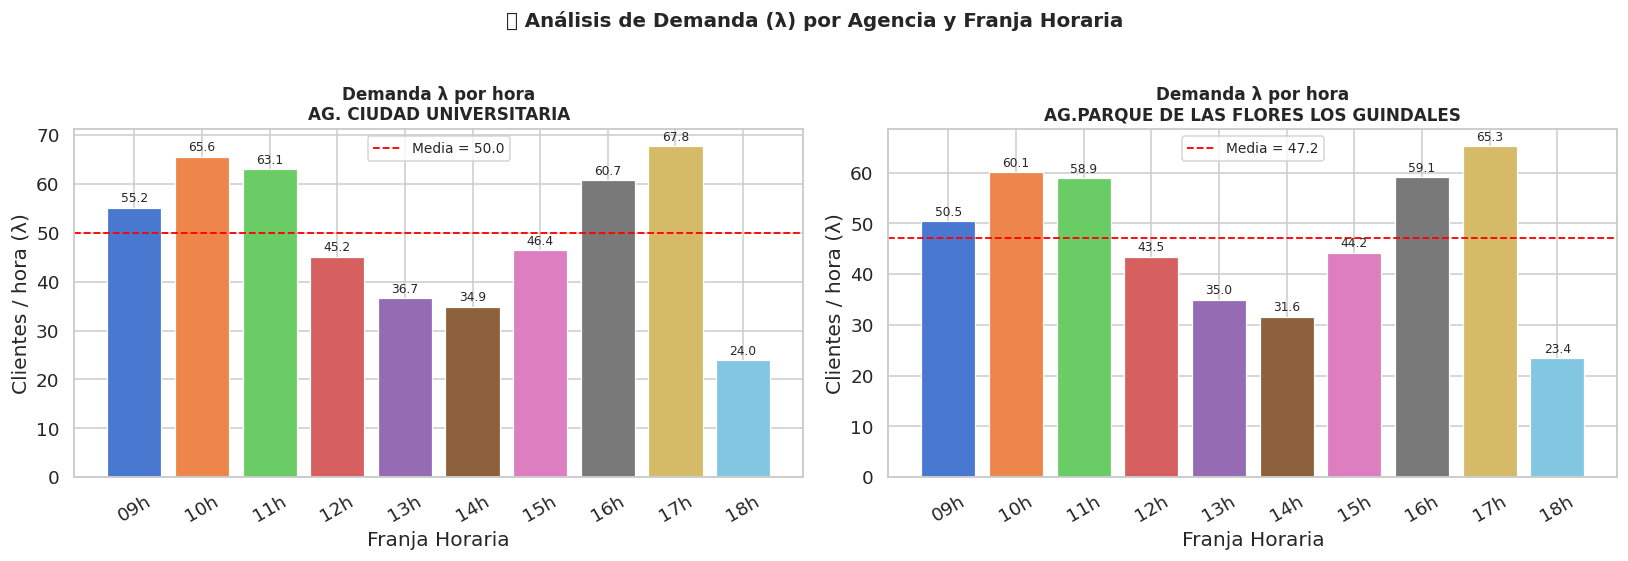

💡 Observación: La demanda máxima ocurre en las franjas de 10h-11h y 16h-17h — horas pico.


In [7]:
# ── Gráfico 1: Lambda por franja horaria y agencia ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (agencia, grupo) in zip(axes, df.groupby('agencia')):
    horas_cortas = [h.split(':')[0] + 'h' for h in grupo['hora'].str[:5]]
    bars = ax.bar(horas_cortas, grupo['lambda'], color=sns.color_palette('muted'), edgecolor='white', linewidth=0.8)
    ax.set_title(f'Demanda λ por hora\n{agencia}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Franja Horaria')
    ax.set_ylabel('Clientes / hora (λ)')
    ax.axhline(grupo['lambda'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Media = {grupo["lambda"].mean():.1f}')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, grupo['lambda']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('📊 Análisis de Demanda (λ) por Agencia y Franja Horaria', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_lambda.png', bbox_inches='tight', dpi=120)
plt.show()
print('💡 Observación: La demanda máxima ocurre en las franjas de 10h-11h y 16h-17h — horas pico.')

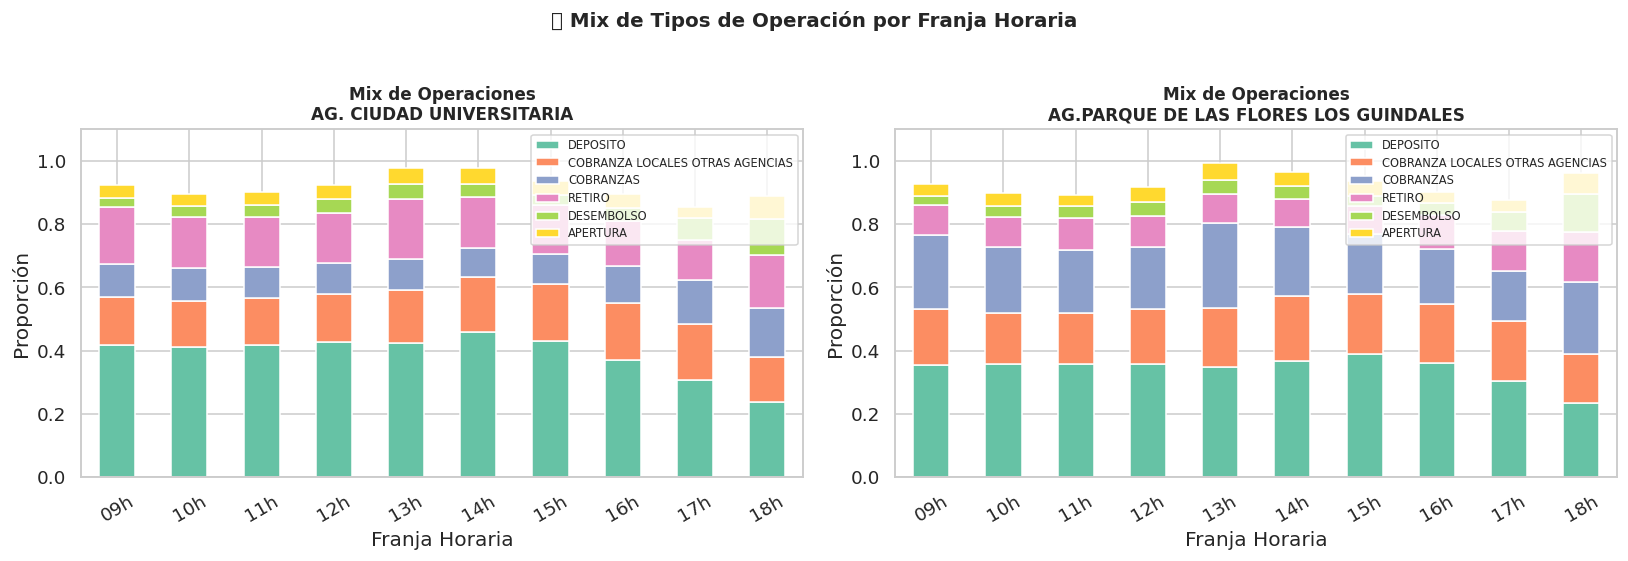

In [4]:
# ── Gráfico 2: Distribución de operaciones (stacked bar) ──────────────────────
horas_cols = [c for c in dist.columns if ':' in c]
tipo_ops   = dist['tipo_ope'].unique()
colores    = sns.color_palette('Set2', len(tipo_ops))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, agencia in zip(axes, dist['agencia'].unique()):
    sub = dist[dist['agencia'] == agencia].set_index('tipo_ope')[horas_cols]
    horas_cortas = [h.split(':')[0] + 'h' for h in horas_cols]
    sub.columns  = horas_cortas
    sub.T.plot(kind='bar', stacked=True, ax=ax, color=colores, edgecolor='white')
    ax.set_title(f'Mix de Operaciones\n{agencia}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Franja Horaria')
    ax.set_ylabel('Proporción')
    ax.legend(fontsize=7.5, loc='upper right')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1.1)

plt.suptitle('📊 Mix de Tipos de Operación por Franja Horaria', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_operaciones.png', bbox_inches='tight', dpi=120)
plt.show()

In [5]:
# ── Verificación: proporciones deben sumar ~1 por franja ─────────────────────
print('Suma de proporciones por agencia/hora (debe ser ≈ 1.0):')
for agencia in dist['agencia'].unique():
    sub = dist[dist['agencia'] == agencia][horas_cols]
    sumas = sub.sum(axis=0)
    print(f'  {agencia[:30]}...: min={sumas.min():.4f}  max={sumas.max():.4f}')

Suma de proporciones por agencia/hora (debe ser ≈ 1.0):
  AG. CIUDAD UNIVERSITARIA...: min=0.8544  max=0.9781
  AG.PARQUE DE LAS FLORES LOS GU...: min=0.8762  max=0.9930


---
## 3. Cálculo de μ Ponderado por Franja Horaria <a id='3'></a>

### ¿Por qué μ es diferente cada hora?

La tasa de servicio **μ** (clientes atendidos por servidor por hora) depende del **tipo de operación** que predomina en cada franja horaria. Una apertura de cuenta tarda ~10 min; un depósito solo ~3 min.

**Fórmula:**
$$\mu_{hora} = \sum_{i} p_i^{hora} \times \mu_i$$

Donde:
- $p_i^{hora}$ = proporción de la operación tipo $i$ en esa franja
- $\mu_i$ = clientes que un servidor puede atender por hora con operación $i$

In [10]:
# ── Tiempos de servicio por tipo de operación (minutos, basado en estándar bancario)
# Fuente: tiempos típicos en banca de ventanilla Latinoamérica
TIEMPOS_SERVICIO = {
    'DEPOSITO'                        : 3.0,   # Depósito simple: 3 min
    'COBRANZA LOCALES OTRAS AGENCIAS' : 4.5,   # Verificación + registro: 4.5 min
    'COBRANZAS'                       : 3.5,   # Cobranzas estándar: 3.5 min
    'RETIRO'                          : 3.0,   # Retiro de efectivo: 3 min
    'DESEMBOLSO'                      : 7.0,   # Desembolso crédito: 7 min
    'APERTURA'                        : 10.0,  # Apertura de cuenta: 10 min
}

# Convertir a clientes/hora por servidor: μ_i = 60 / tiempo_i
MU_POR_TIPO = {op: 60 / t for op, t in TIEMPOS_SERVICIO.items()}
print('Tasa de servicio μ por tipo de operación (clientes/hora):')
for op, mu in MU_POR_TIPO.items():
    print(f'  {op:<40} {mu:.2f} clientes/h  ({TIEMPOS_SERVICIO[op]} min/cliente)')

Tasa de servicio μ por tipo de operación (clientes/hora):
  DEPOSITO                                 20.00 clientes/h  (3.0 min/cliente)
  COBRANZA LOCALES OTRAS AGENCIAS          13.33 clientes/h  (4.5 min/cliente)
  COBRANZAS                                17.14 clientes/h  (3.5 min/cliente)
  RETIRO                                   20.00 clientes/h  (3.0 min/cliente)
  DESEMBOLSO                               8.57 clientes/h  (7.0 min/cliente)
  APERTURA                                 6.00 clientes/h  (10.0 min/cliente)


In [ ]:
# ── Calcular μ ponderado para cada agencia y franja horaria ───────────────────
registros_mu = []

for agencia in dist['agencia'].unique():
    sub = dist[dist['agencia'] == agencia].copy()
    for hora in horas_cols:
        props = dict(zip(sub['tipo_ope'], sub[hora]))
        mu_pond = sum(props.get(op, 0) * MU_POR_TIPO.get(op, 0) for op in MU_POR_TIPO)
        registros_mu.append({'agencia': agencia, 'hora': hora, 'mu': mu_pond})

df_mu = pd.DataFrame(registros_mu)

# Merge con df principal
df['hora_key'] = df['hora'].str.strip()
df_mu['hora_key'] = df_mu['hora'].str.strip()
df_main = df.merge(df_mu[['agencia', 'hora_key', 'mu']], 
                   left_on=['agencia', 'hora_key'], 
                   right_on=['agencia', 'hora_key'], how='left')
df_main.drop('hora_key', axis=1, inplace=True)

print('Dataset con μ calculado:')
display(df_main[['agencia','hora','lambda','mu','servidores','cs','cq']].round(3))

Dataset con μ calculado:


,agencia,hora,lambda,mu,servidores,cs,cq
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,15.846,5,13.64,27.29
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,15.327,5,13.64,27.29
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,15.265,5,13.64,27.29
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,15.454,5,13.64,27.29
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,16.593,5,13.64,27.29
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,16.209,5,13.64,27.29
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,15.889,5,13.64,27.29
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,15.350,5,13.64,27.29
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,14.597,5,13.64,27.29
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,15.243,5,13.64,27.29


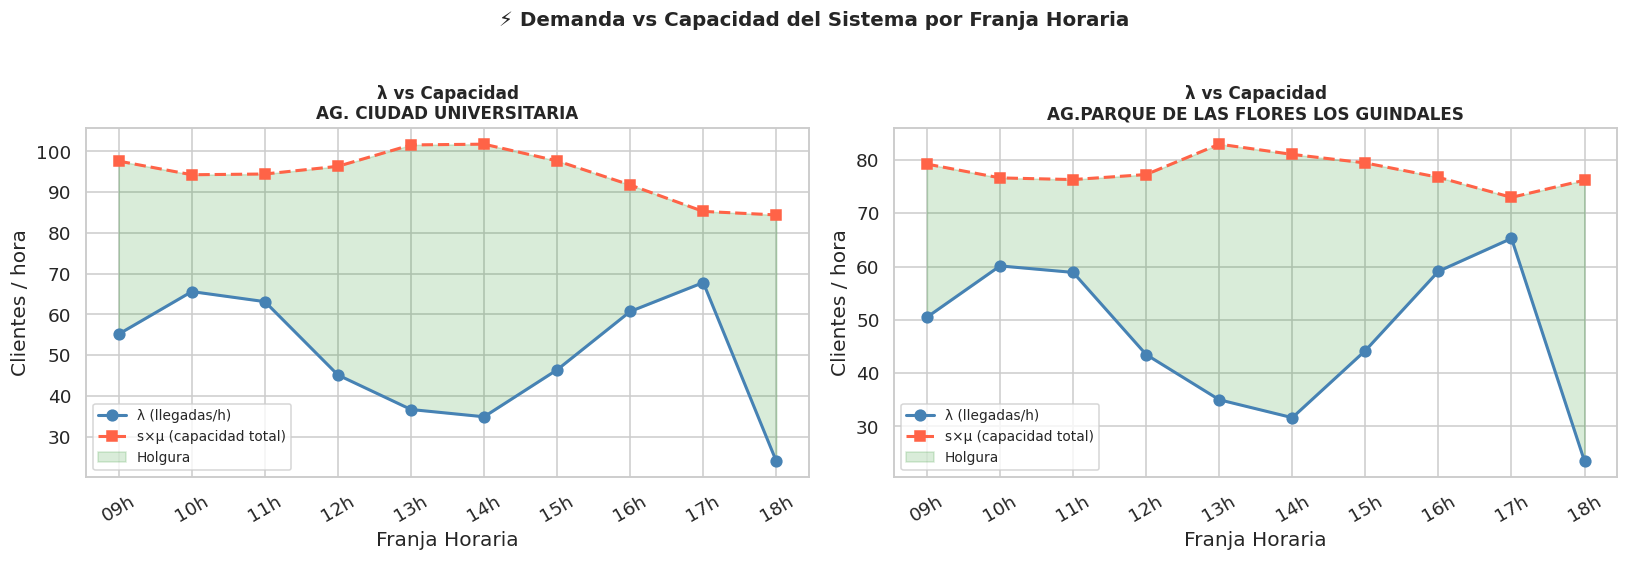

In [12]:
# ── Gráfico: μ vs λ por hora ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (agencia, g) in zip(axes, df_main.groupby('agencia')):
    horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
    x = np.arange(len(horas_c))
    ax.plot(x, g['lambda'].values, 'o-', color='steelblue', linewidth=2, markersize=7, label='λ (llegadas/h)')
    # Capacidad total del sistema = s × μ
    capacidad = g['servidores'].values * g['mu'].values
    ax.plot(x, capacidad, 's--', color='tomato', linewidth=2, markersize=7, label='s×μ (capacidad total)')
    ax.fill_between(x, g['lambda'].values, capacidad, alpha=0.15, color='green', label='Holgura')
    ax.set_xticks(x); ax.set_xticklabels(horas_c, rotation=30)
    ax.set_title(f'λ vs Capacidad\n{agencia}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Franja Horaria'); ax.set_ylabel('Clientes / hora')
    ax.legend(fontsize=9)

plt.suptitle('⚡ Demanda vs Capacidad del Sistema por Franja Horaria', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_capacidad.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 4. Modelo M/M/s — Fórmulas Analíticas <a id='4'></a>

### Fundamento teórico

El modelo **M/M/s** asume:
- **M** (Markov) llegadas: proceso de Poisson con tasa λ
- **M** (Markov) servicio: tiempo exponencial con tasa μ por servidor
- **s** servidores en paralelo, cola FIFO infinita

### Fórmulas del modelo

| Símbolo | Nombre | Fórmula |
|---------|--------|---------|
| ρ | Intensidad de tráfico | λ / (s·μ) — debe ser < 1 |
| a | Carga ofrecida | λ / μ |
| P₀ | Prob. sistema vacío | Ver fórmula Erlang-C |
| Lq | Clientes en cola | P₀ · (a^s · ρ) / (s! · (1−ρ)²) |
| Ls | Clientes en sistema | Lq + a |
| Wq | Tiempo en cola | Lq / λ |
| Ws | Tiempo en sistema | Wq + 1/μ |
| Serv. ocupados | Servidores usando | a = λ/μ |
| Serv. ociosos | Servidores libres | s − a |
| CTS | Costo servidores | s · Cs |
| CTS_idle | Costo servidores ociosos | (s−a) · Cs |
| CTQ | Costo espera clientes | Lq · Cq |
| CT | Costo total | CTS + CTQ |

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║           FUNCIONES CENTRALES DEL MODELO M/M/s                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def calcular_P0(lam: float, mu: float, s: int) -> float:
    """
    Calcula P0: probabilidad de que el sistema esté completamente vacío.
    
    Fórmula:
        P0 = 1 / [Σ_{n=0}^{s-1} (a^n / n!) + (a^s / s!) * (1 / (1 - ρ))]
    
    Donde a = λ/μ  y  ρ = λ/(s·μ)
    """
    a   = lam / mu
    rho = lam / (s * mu)
    if rho >= 1:
        return 0.0  # Sistema inestable
    
    suma = sum((a**n) / math.factorial(n) for n in range(s))
    ultimo = (a**s) / (math.factorial(s) * (1 - rho))
    return 1.0 / (suma + ultimo)


def mms(lam: float, mu: float, s: int, Cs: float, Cq: float) -> dict:
    """
    Calcula todas las métricas del modelo M/M/s.
    
    Parámetros:
    -----------
    lam : float  — tasa de llegadas λ (clientes/hora)
    mu  : float  — tasa de servicio μ por servidor (clientes/hora)
    s   : int    — número de servidores
    Cs  : float  — costo por servidor (PEN/hora)
    Cq  : float  — costo de espera por cliente en cola (PEN/hora)
    
    Retorna:
    --------
    dict con todas las métricas del sistema
    """
    a   = lam / mu           # Carga ofrecida (servidores necesarios sin holgura)
    rho = lam / (s * mu)     # Factor de utilización por servidor
    
    estable = rho < 1        # Condición de estabilidad
    
    if not estable:
        # Sistema saturado: cola crece infinitamente
        return {
            'lambda': lam, 'mu': mu, 's': s, 'a': a, 'rho': rho,
            'estable': False,
            'P0': 0, 'Lq': np.inf, 'Ls': np.inf,
            'Wq_min': np.inf, 'Ws_min': np.inf,
            'serv_ocupados': a, 'serv_ociosos': max(0, s - a),
            'CTS': s * Cs, 'CTS_idle': max(0, s - a) * Cs,
            'CTQ': np.inf, 'CT': np.inf
        }
    
    P0 = calcular_P0(lam, mu, s)
    
    # ── Número promedio de clientes en cola (Erlang-C)
    Lq = P0 * (a**s * rho) / (math.factorial(s) * (1 - rho)**2)
    
    # ── Número promedio de clientes en sistema
    Ls = Lq + a
    
    # ── Tiempo promedio en cola (horas → convertir a minutos)
    Wq_h   = Lq / lam          # horas
    Wq_min = Wq_h * 60         # minutos
    
    # ── Tiempo promedio en sistema
    Ws_h   = Wq_h + 1/mu       # horas
    Ws_min = Ws_h * 60         # minutos
    
    # ── Servidores ocupados y ociosos
    serv_ocupados = a                  # E[servidores trabajando] = λ/μ
    serv_ociosos  = s - serv_ocupados  # servidores libres en promedio
    
    # ── Costos
    CTS      = s * Cs                  # Costo total de servidores activos
    CTS_idle = serv_ociosos * Cs       # Costo de servidores ociosos (desperdicio)
    CTQ      = Lq * Cq                 # Costo de espera de clientes en cola
    CT       = CTS + CTQ               # Costo total del sistema
    
    return {
        'lambda'        : lam,
        'mu'            : round(mu, 4),
        's'             : s,
        'a'             : round(a, 4),
        'rho'           : round(rho, 4),
        'estable'       : True,
        'P0'            : round(P0, 6),
        'Lq'            : round(Lq, 4),
        'Ls'            : round(Ls, 4),
        'Wq_min'        : round(Wq_min, 4),
        'Ws_min'        : round(Ws_min, 4),
        'serv_ocupados' : round(serv_ocupados, 4),
        'serv_ociosos'  : round(serv_ociosos, 4),
        'CTS'           : round(CTS, 4),
        'CTS_idle'      : round(CTS_idle, 4),
        'CTQ'           : round(CTQ, 4),
        'CT'            : round(CT, 4),
    }

print('✅ Funciones del modelo M/M/s definidas')
print()
# ── Prueba rápida ──────────────────────────────────────────────────────────────
test = mms(lam=50, mu=20, s=4, Cs=13.64, Cq=27.29)
print('Prueba con λ=50, μ=20, s=4:')
for k, v in test.items():
    print(f'  {k:<20} {v}')

✅ Funciones del modelo M/M/s definidas

Prueba con λ=50, μ=20, s=4:
  lambda               50
  mu                   20
  s                    4
  a                    2.5
  rho                  0.625
  estable              True
  P0                   0.073695
  Lq                   0.5331
  Ls                   3.0331
  Wq_min               0.6397
  Ws_min               3.6397
  serv_ocupados        2.5
  serv_ociosos         1.5
  CTS                  54.56
  CTS_idle             20.46
  CTQ                  14.5481
  CT                   69.1081


In [14]:
# ── Aplicar modelo a TODOS los registros del dataset ──────────────────────────
resultados = []
for _, row in df_main.iterrows():
    res = mms(
        lam=row['lambda'], mu=row['mu'],
        s=int(row['servidores']),
        Cs=row['cs'], Cq=row['cq']
    )
    res['agencia'] = row['agencia']
    res['hora']    = row['hora']
    resultados.append(res)

df_res = pd.DataFrame(resultados)

# Reordenar columnas
cols_orden = ['agencia','hora','lambda','mu','s','a','rho','estable',
              'P0','Lq','Ls','Wq_min','Ws_min',
              'serv_ocupados','serv_ociosos',
              'CTS','CTS_idle','CTQ','CT']
df_res = df_res[cols_orden]

print('=== Resultados del Modelo M/M/s — Configuración Actual ===')
display(df_res.round(3))

=== Resultados del Modelo M/M/s — Configuración Actual ===


,agencia,hora,lambda,mu,s,a,rho,estable,P0,Lq,Ls,Wq_min,Ws_min,serv_ocupados,serv_ociosos,CTS,CTS_idle,CTQ,CT
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,15.846,5,3.187,0.637,True,0.038,0.501,3.688,0.595,4.382,3.187,1.813,68.20,24.730,13.670,81.870
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,15.327,5,3.922,0.784,True,0.015,1.909,5.832,1.906,5.820,3.922,1.078,68.20,14.698,52.108,120.308
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,15.265,5,3.859,0.772,True,0.016,1.693,5.552,1.725,5.655,3.859,1.141,68.20,15.569,46.207,114.407
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,15.454,5,2.814,0.563,True,0.057,0.248,3.061,0.342,4.224,2.814,2.186,68.20,29.824,6.759,74.959
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,16.594,5,2.109,0.422,True,0.120,0.053,2.162,0.090,3.706,2.109,2.891,68.20,39.430,1.440,69.640
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,16.209,5,1.952,0.390,True,0.141,0.035,1.987,0.066,3.768,1.952,3.048,68.20,41.575,0.955,69.155
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,15.889,5,2.784,0.557,True,0.059,0.234,3.017,0.317,4.093,2.784,2.216,68.20,30.230,6.374,74.574
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,15.350,5,3.851,0.770,True,0.016,1.669,5.520,1.694,5.603,3.851,1.149,68.20,15.674,45.550,113.750
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,14.597,5,4.472,0.894,True,0.005,6.356,10.829,5.842,9.953,4.472,0.528,68.20,7.199,173.466,241.666
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,15.243,5,1.538,0.308,True,0.214,0.010,1.548,0.025,3.962,1.538,3.462,68.20,47.216,0.270,68.470


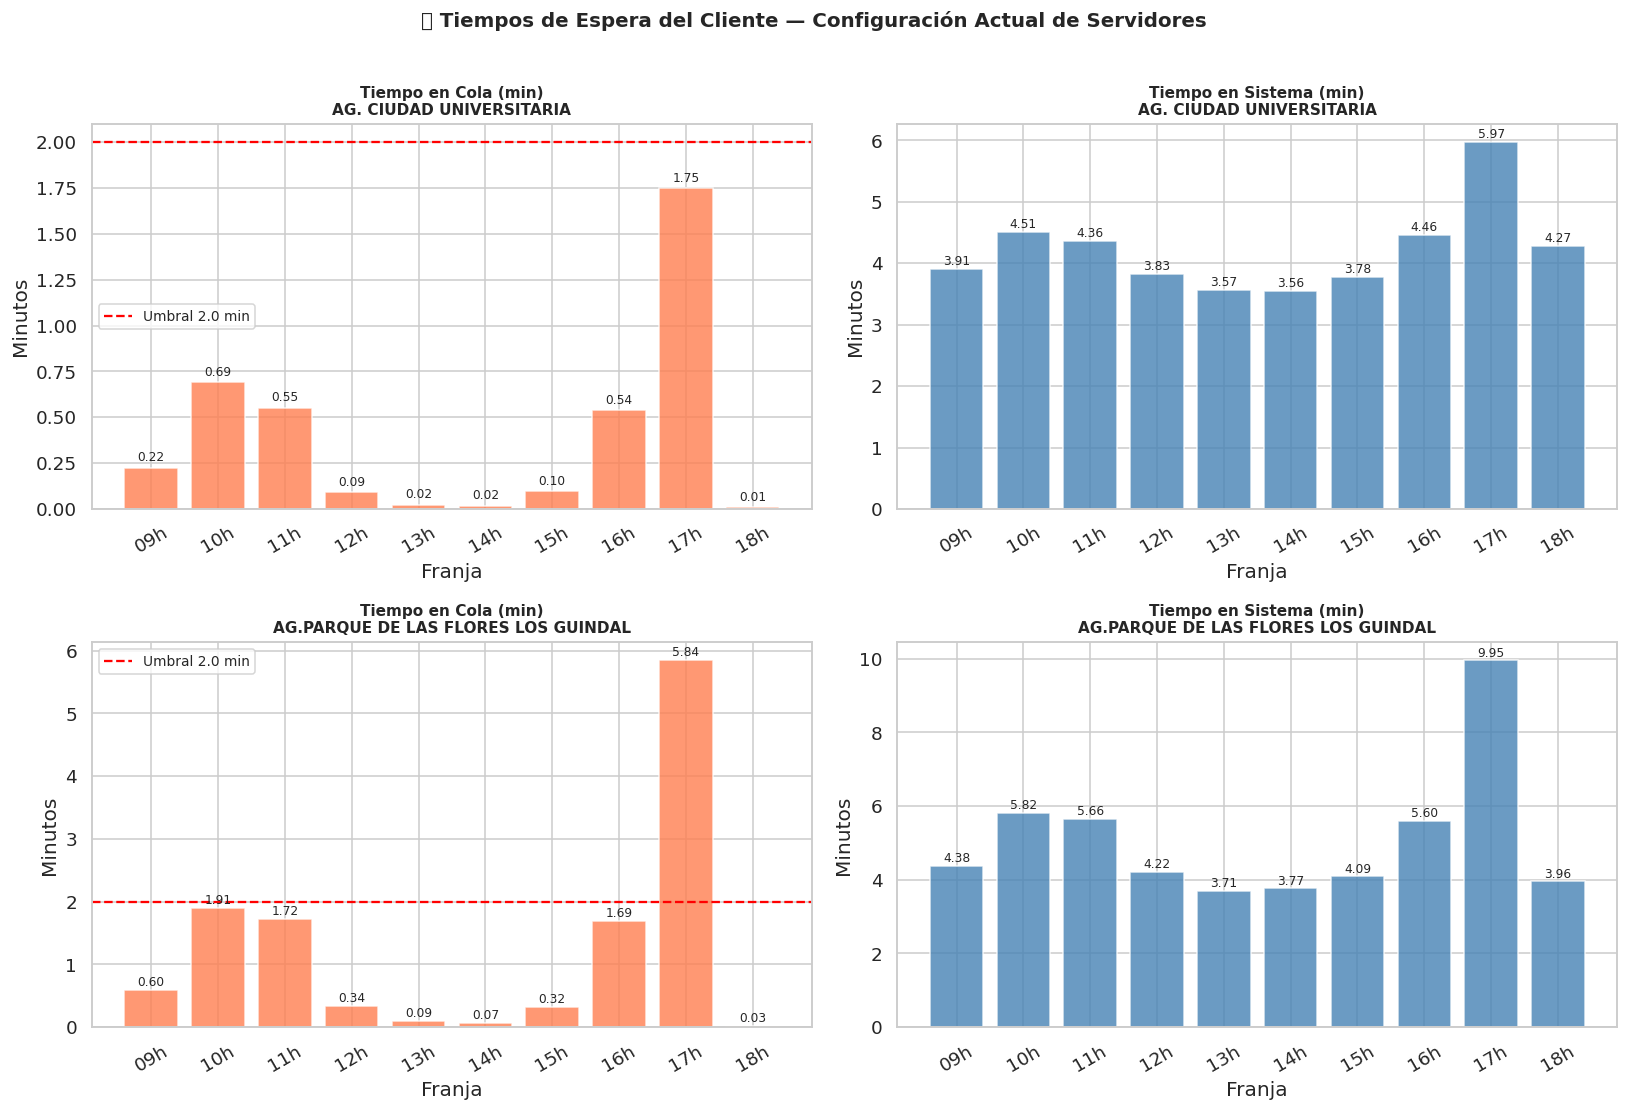

In [15]:
# ── Gráfico: Tiempos de espera y en sistema ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metricas = [('Wq_min', 'Tiempo en Cola (min)', 'coral', 2.0),
            ('Ws_min', 'Tiempo en Sistema (min)', 'steelblue', None)]

for col_idx, (metrica, titulo, color, umbral) in enumerate(metricas):
    for row_idx, (agencia, g) in enumerate(df_res.groupby('agencia')):
        ax = axes[row_idx][col_idx]
        horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
        ax.bar(horas_c, g[metrica], color=color, alpha=0.8, edgecolor='white')
        if umbral:
            ax.axhline(umbral, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {umbral} min')
            ax.legend(fontsize=9)
        ax.set_title(f'{titulo}\n{agencia[:35]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Franja')
        ax.set_ylabel('Minutos')
        ax.tick_params(axis='x', rotation=30)
        for i, (x, y) in enumerate(zip(horas_c, g[metrica])):
            ax.text(i, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('⏱️ Tiempos de Espera del Cliente — Configuración Actual de Servidores',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tiempos_espera.png', bbox_inches='tight', dpi=120)
plt.show()

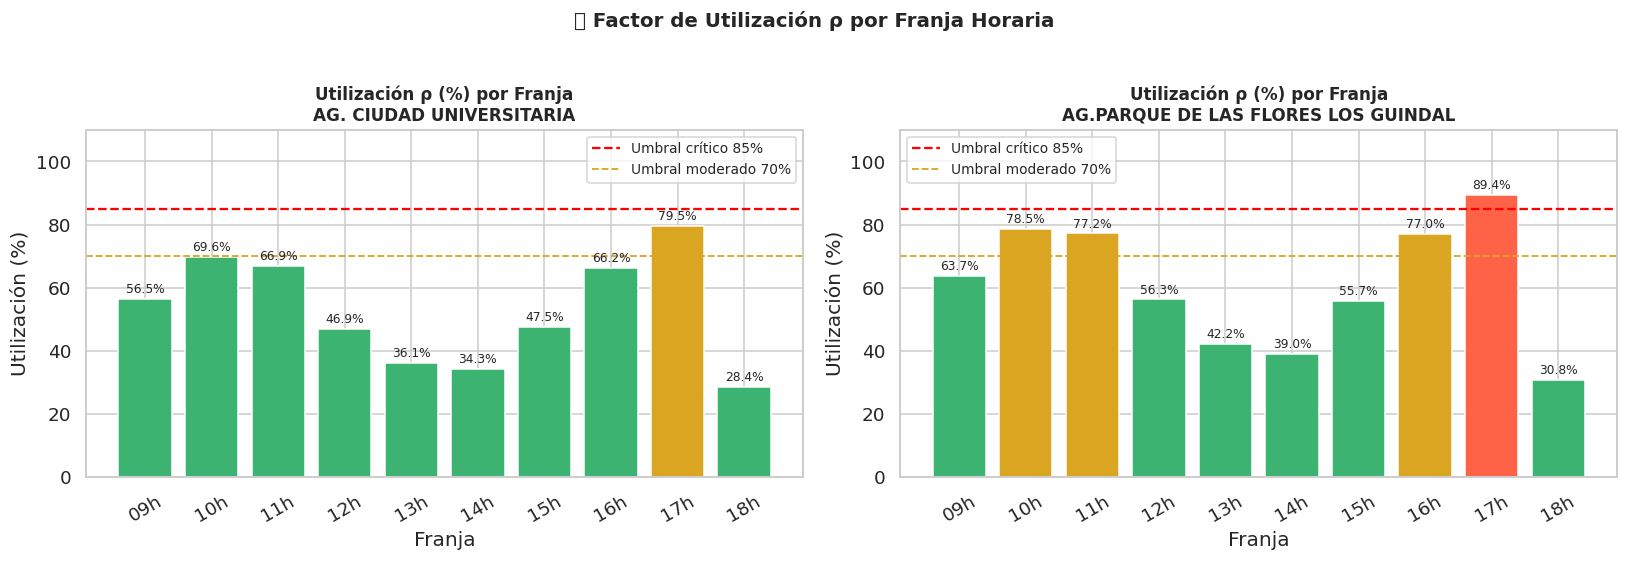

🔴 Rojo: ρ > 85% → Alta saturación, clientes esperan mucho
🟡 Amarillo: ρ 70-85% → Carga moderada-alta
🟢 Verde: ρ < 70% → Sistema fluido


In [16]:
# ── Gráfico: ρ (utilización) por franja ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (agencia, g) in zip(axes, df_res.groupby('agencia')):
    horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
    colores_rho = ['tomato' if r > 0.85 else 'goldenrod' if r > 0.70 else 'mediumseagreen'
                   for r in g['rho']]
    bars = ax.bar(horas_c, g['rho'] * 100, color=colores_rho, edgecolor='white')
    ax.axhline(85, color='red', linestyle='--', linewidth=1.5, label='Umbral crítico 85%')
    ax.axhline(70, color='goldenrod', linestyle='--', linewidth=1.2, label='Umbral moderado 70%')
    ax.set_title(f'Utilización ρ (%) por Franja\n{agencia[:35]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Franja')
    ax.set_ylabel('Utilización (%)')
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    for i, (bar, r) in enumerate(zip(bars, g['rho'])):
        ax.text(i, r*100 + 1, f'{r*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('🔥 Factor de Utilización ρ por Franja Horaria', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('utilizacion_rho.png', bbox_inches='tight', dpi=120)
plt.show()

print('🔴 Rojo: ρ > 85% → Alta saturación, clientes esperan mucho')
print('🟡 Amarillo: ρ 70-85% → Carga moderada-alta')
print('🟢 Verde: ρ < 70% → Sistema fluido')

---
## 5. Optimización de Servidores <a id='5'></a>

**Objetivo:** Para cada franja horaria y agencia, encontrar el número de servidores `s*` que **minimice el costo total (CT = CTS + CTQ)**.

La función de costo total tiene forma de **U** respecto a `s`:
- Con pocos servidores: CTQ sube (clientes esperan mucho)
- Con muchos servidores: CTS sube (servidores ociosos costosos)
- El mínimo es el punto óptimo `s*`

In [17]:
def optimizar_servidores(lam, mu, Cs, Cq, s_max=15):
    """
    Encuentra el número óptimo de servidores s* que minimiza CT.
    Busca desde s_min (mínimo para estabilidad) hasta s_max.
    """
    # Mínimo s para que el sistema sea estable
    s_min = max(1, math.ceil(lam / mu) + 1)
    
    resultados = []
    for s in range(s_min, s_max + 1):
        r = mms(lam, mu, s, Cs, Cq)
        if r['estable']:
            resultados.append(r)
    
    if not resultados:
        return None, None
    
    # Servidor óptimo = mínimo CT
    df_opt = pd.DataFrame(resultados)
    idx_opt = df_opt['CT'].idxmin()
    return int(df_opt.loc[idx_opt, 's']), df_opt


# ── Calcular s* para todas las filas ──────────────────────────────────────────
registros_opt = []
for _, row in df_main.iterrows():
    s_opt, df_curvas = optimizar_servidores(
        lam=row['lambda'], mu=row['mu'],
        Cs=row['cs'], Cq=row['cq']
    )
    # Métricas con s actual
    res_actual = mms(row['lambda'], row['mu'], int(row['servidores']), row['cs'], row['cq'])
    # Métricas con s óptimo
    res_opt    = mms(row['lambda'], row['mu'], s_opt, row['cs'], row['cq'])
    
    registros_opt.append({
        'agencia'           : row['agencia'],
        'hora'              : row['hora'],
        'lambda'            : row['lambda'],
        'mu'                : round(row['mu'], 4),
        's_actual'          : int(row['servidores']),
        's_optimo'          : s_opt,
        'delta_s'           : s_opt - int(row['servidores']),
        'CT_actual'         : res_actual['CT'],
        'CT_optimo'         : res_opt['CT'],
        'ahorro_CT'         : round(res_actual['CT'] - res_opt['CT'], 4),
        'Wq_actual_min'     : res_actual['Wq_min'],
        'Wq_optimo_min'     : res_opt['Wq_min'],
        'rho_actual'        : res_actual['rho'],
        'rho_optimo'        : res_opt['rho'],
        'serv_ociosos_actual': res_actual['serv_ociosos'],
        'serv_ociosos_opt'  : res_opt['serv_ociosos'],
    })

df_opt = pd.DataFrame(registros_opt)

print('=== Comparación: Servidores Actuales vs Óptimos ===')
display(df_opt.round(3))

=== Comparación: Servidores Actuales vs Óptimos ===


,agencia,hora,lambda,mu,s_actual,s_optimo,delta_s,CT_actual,CT_optimo,ahorro_CT,Wq_actual_min,Wq_optimo_min,rho_actual,rho_optimo,serv_ociosos_actual,serv_ociosos_opt
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,15.846,5,5,0,81.870,81.870,0.000,0.595,0.595,0.637,0.637,1.813,1.813
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,15.327,5,6,1,120.308,95.553,24.755,1.906,0.501,0.784,0.654,1.078,2.078
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,15.265,5,6,1,114.407,94.202,20.204,1.725,0.462,0.772,0.643,1.141,2.141
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,15.454,5,5,0,74.959,74.959,0.000,0.342,0.342,0.563,0.563,2.186,2.186
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,16.594,5,4,-1,69.640,60.706,8.933,0.090,0.386,0.422,0.527,2.891,1.891
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,16.209,5,4,-1,69.155,58.782,10.373,0.066,0.293,0.390,0.488,3.048,2.048
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,15.889,5,5,0,74.574,74.574,0.000,0.317,0.317,0.557,0.557,2.216,2.216
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,15.350,5,6,1,113.750,94.049,19.701,1.694,0.454,0.770,0.642,1.149,2.149
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,14.597,5,7,2,241.666,105.717,135.950,5.842,0.345,0.894,0.639,0.528,2.528
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,15.243,5,3,-2,68.470,48.123,20.346,0.025,0.675,0.308,0.513,3.462,1.462


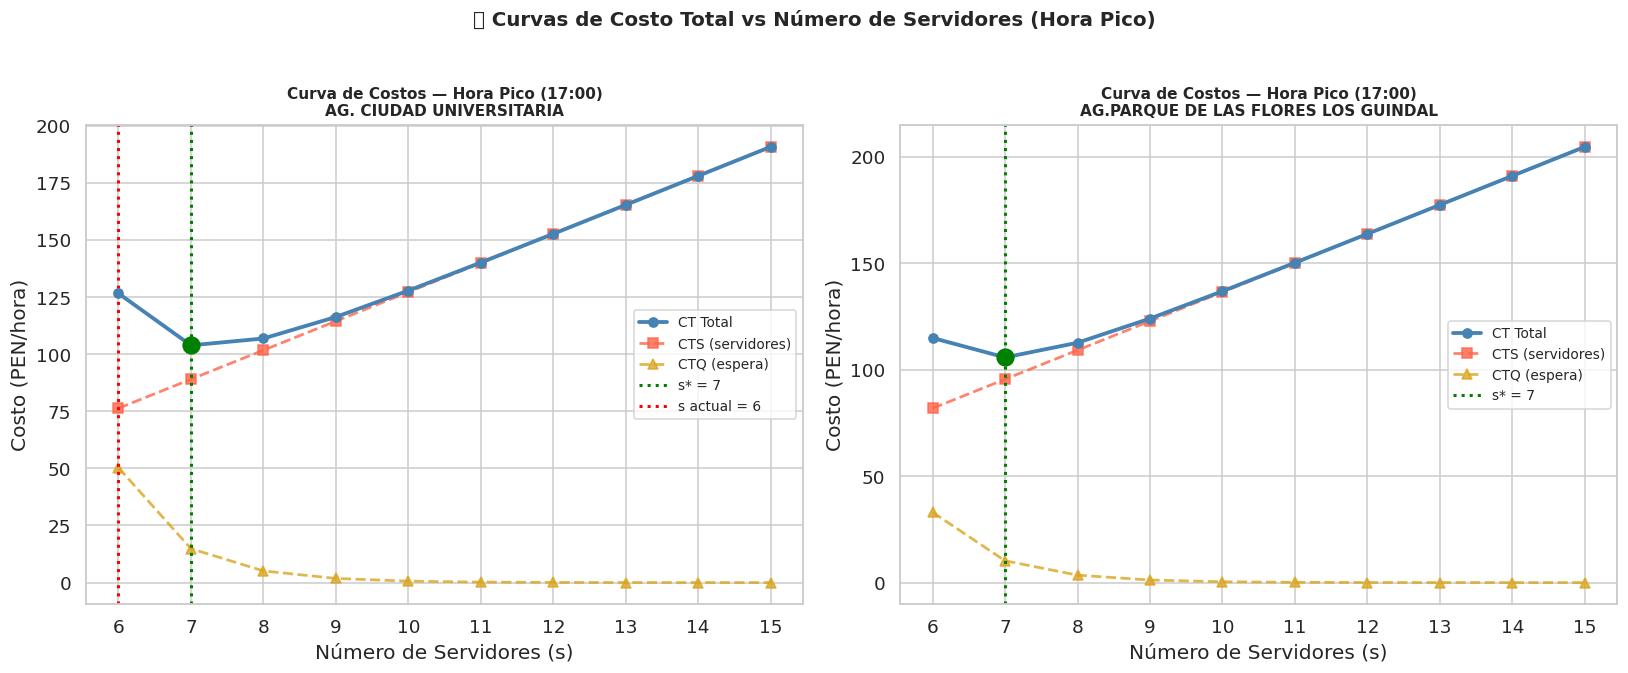

In [18]:
# ── Gráfico: Curvas de costo para una franja representativa ───────────────────
# Tomamos la hora pico de cada agencia
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (agencia, g) in zip(axes, df_main.groupby('agencia')):
    # Hora pico = máximo lambda
    fila_pico = g.loc[g['lambda'].idxmax()]
    hora_pico = fila_pico['hora']
    lam_pico  = fila_pico['lambda']
    mu_pico   = fila_pico['mu']
    Cs        = fila_pico['cs']
    Cq        = fila_pico['cq']
    
    s_opt_pico, df_curvas = optimizar_servidores(lam_pico, mu_pico, Cs, Cq)
    
    ax.plot(df_curvas['s'], df_curvas['CT'],  'o-', color='steelblue', linewidth=2.5, label='CT Total', zorder=5)
    ax.plot(df_curvas['s'], df_curvas['CTS'], 's--', color='tomato', linewidth=1.8, alpha=0.8, label='CTS (servidores)')
    ax.plot(df_curvas['s'], df_curvas['CTQ'], '^--', color='goldenrod', linewidth=1.8, alpha=0.8, label='CTQ (espera)')
    
    # Marcar s óptimo
    ct_min = df_curvas.loc[df_curvas['s'] == s_opt_pico, 'CT'].values[0]
    ax.axvline(s_opt_pico, color='green', linestyle=':', linewidth=2, label=f's* = {s_opt_pico}')
    ax.scatter([s_opt_pico], [ct_min], color='green', s=120, zorder=10)
    
    # Marcar s actual
    s_actual = int(g.loc[g['lambda'].idxmax(), 'servidores'])
    ct_actual = df_curvas.loc[df_curvas['s'] == s_actual, 'CT'].values
    if len(ct_actual):
        ax.axvline(s_actual, color='red', linestyle=':', linewidth=2, label=f's actual = {s_actual}')
    
    ax.set_title(f'Curva de Costos — Hora Pico ({hora_pico[:5]})\n{agencia[:35]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Número de Servidores (s)')
    ax.set_ylabel('Costo (PEN/hora)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('💰 Curvas de Costo Total vs Número de Servidores (Hora Pico)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_costo.png', bbox_inches='tight', dpi=120)
plt.show()

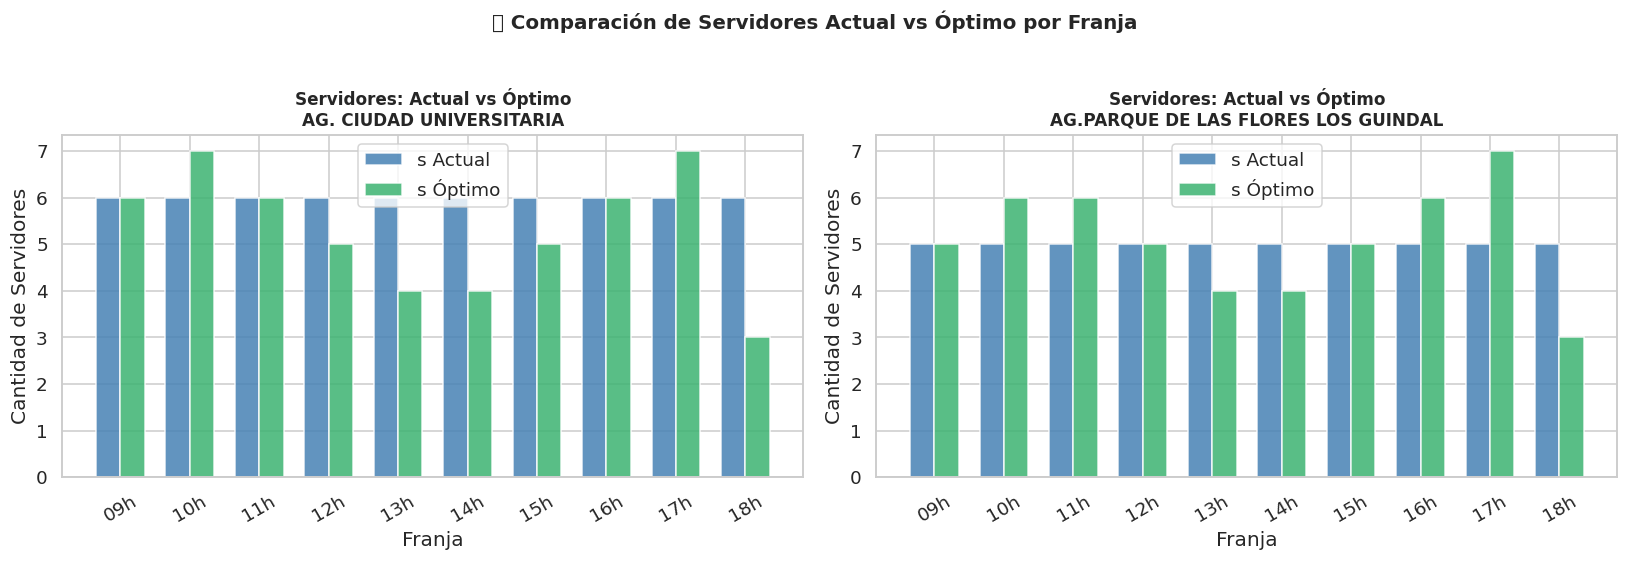

In [19]:
# ── Gráfico: s actual vs s óptimo por franja ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (agencia, g) in zip(axes, df_opt.groupby('agencia')):
    horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
    x = np.arange(len(horas_c))
    w = 0.35
    ax.bar(x - w/2, g['s_actual'], w, label='s Actual', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, g['s_optimo'], w, label='s Óptimo', color='mediumseagreen', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(horas_c, rotation=30)
    ax.set_title(f'Servidores: Actual vs Óptimo\n{agencia[:35]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Franja'); ax.set_ylabel('Cantidad de Servidores')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend()

plt.suptitle('👥 Comparación de Servidores Actual vs Óptimo por Franja', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('servidores_comparacion.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Decisión: ¿Contratar Auxiliar de Operaciones? <a id='6'></a>

**Criterio de decisión:**
La gerencia debe contratar un auxiliar adicional si en una franja horaria:

1. **`s_optimo > s_actual`**: el modelo recomienda más servidores de los disponibles.
2. **`Wq > umbral_espera`**: el tiempo en cola supera el estándar de calidad (ej. 2 min).
3. **`rho > 0.85`**: alta saturación del sistema.
4. **El costo de no contratar (`CTQ`) supera el costo de contratar (`Cs`)**: económicamente viable.

In [20]:
# ── Parámetros de decisión ────────────────────────────────────────────────────
UMBRAL_ESPERA_MIN  = 2.0   # Tiempo máximo aceptable en cola (minutos)
UMBRAL_RHO         = 0.85  # Utilización crítica

def decision_auxiliar(row):
    """
    Evalúa si se debe contratar auxiliar para una franja horaria dada.
    Retorna etiqueta y razón.
    """
    razones = []
    
    if row['s_optimo'] > row['s_actual']:
        razones.append(f'Necesita +{row["s_optimo"]-row["s_actual"]} servidor(es) (s*={row["s_optimo"]})')
    if row['Wq_actual_min'] > UMBRAL_ESPERA_MIN:
        razones.append(f'Wq={row["Wq_actual_min"]:.2f} min > umbral {UMBRAL_ESPERA_MIN} min')
    if row['rho_actual'] > UMBRAL_RHO:
        razones.append(f'ρ={row["rho_actual"]:.2%} > {UMBRAL_RHO:.0%}')
    if row['ahorro_CT'] > row.get('Cs_proxy', 0):  
        razones.append(f'Ahorro CT={row["ahorro_CT"]:.2f} PEN/h')
    
    if razones:
        return 'SÍ CONTRATAR', ' | '.join(razones)
    return 'NO CONTRATAR', 'Sistema dentro de parámetros óptimos'

# Añadir Cs como proxy para el análisis (del df_main)
df_opt2 = df_opt.copy()
df_opt2['Cs_proxy'] = df_main['cs'].values

df_opt2[['decision','razon']] = df_opt2.apply(
    lambda r: pd.Series(decision_auxiliar(r)), axis=1
)

print('=== DECISIÓN: ¿Contratar Auxiliar? ===')
cols_dec = ['agencia','hora','s_actual','s_optimo','delta_s',
            'Wq_actual_min','rho_actual','ahorro_CT','decision','razon']
display(df_opt2[cols_dec].round(3))

=== DECISIÓN: ¿Contratar Auxiliar? ===


,agencia,hora,s_actual,s_optimo,delta_s,Wq_actual_min,rho_actual,ahorro_CT,decision,razon
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,5,5,0,0.595,0.637,0.000,NO CONTRATAR,Sistema dentro de parámetros óptimos
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,5,6,1,1.906,0.784,24.755,SÍ CONTRATAR,Necesita +1 servidor(es) (s*=6) | Ahorro CT=24...
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,5,6,1,1.725,0.772,20.204,SÍ CONTRATAR,Necesita +1 servidor(es) (s*=6) | Ahorro CT=20...
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,5,5,0,0.342,0.563,0.000,NO CONTRATAR,Sistema dentro de parámetros óptimos
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,5,4,-1,0.090,0.422,8.933,NO CONTRATAR,Sistema dentro de parámetros óptimos
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,5,4,-1,0.066,0.390,10.373,NO CONTRATAR,Sistema dentro de parámetros óptimos
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,5,5,0,0.317,0.557,0.000,NO CONTRATAR,Sistema dentro de parámetros óptimos
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,5,6,1,1.694,0.770,19.701,SÍ CONTRATAR,Necesita +1 servidor(es) (s*=6) | Ahorro CT=19...
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,5,7,2,5.842,0.894,135.950,SÍ CONTRATAR,Necesita +2 servidor(es) (s*=7) | Wq=5.84 min ...
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,5,3,-2,0.025,0.308,20.346,SÍ CONTRATAR,Ahorro CT=20.35 PEN/h


In [21]:
# ── Resumen ejecutivo por agencia ─────────────────────────────────────────────
print('\n' + '='*70)
print('📋 RESUMEN EJECUTIVO — RECOMENDACIÓN DE CONTRATACIÓN')
print('='*70)
for agencia, g in df_opt2.groupby('agencia'):
    n_contratar = (g['decision'] == 'SÍ CONTRATAR').sum()
    n_total     = len(g)
    ahorro_total = g.loc[g['decision']=='SÍ CONTRATAR','ahorro_CT'].sum()
    horas_criticas = g.loc[g['decision']=='SÍ CONTRATAR','hora'].str[:5].tolist()
    
    print(f'\n🏦 {agencia}')
    print(f'   Franjas que requieren auxiliar: {n_contratar}/{n_total}')
    print(f'   Horas críticas: {horas_criticas}')
    print(f'   Ahorro potencial CT: S/ {ahorro_total:.2f}/hora')
    print(f'   Tiempo promedio en cola (máx): {g["Wq_actual_min"].max():.2f} min')


📋 RESUMEN EJECUTIVO — RECOMENDACIÓN DE CONTRATACIÓN

🏦 AG. CIUDAD UNIVERSITARIA
   Franjas que requieren auxiliar: 5/10
   Horas críticas: ['10:00', '13:00', '14:00', '17:00', '18:00']
   Ahorro potencial CT: S/ 90.70/hora
   Tiempo promedio en cola (máx): 1.75 min

🏦 AG.PARQUE DE LAS FLORES LOS GUINDALES
   Franjas que requieren auxiliar: 5/10
   Horas críticas: ['10:00', '11:00', '16:00', '17:00', '18:00']
   Ahorro potencial CT: S/ 220.96/hora
   Tiempo promedio en cola (máx): 5.84 min


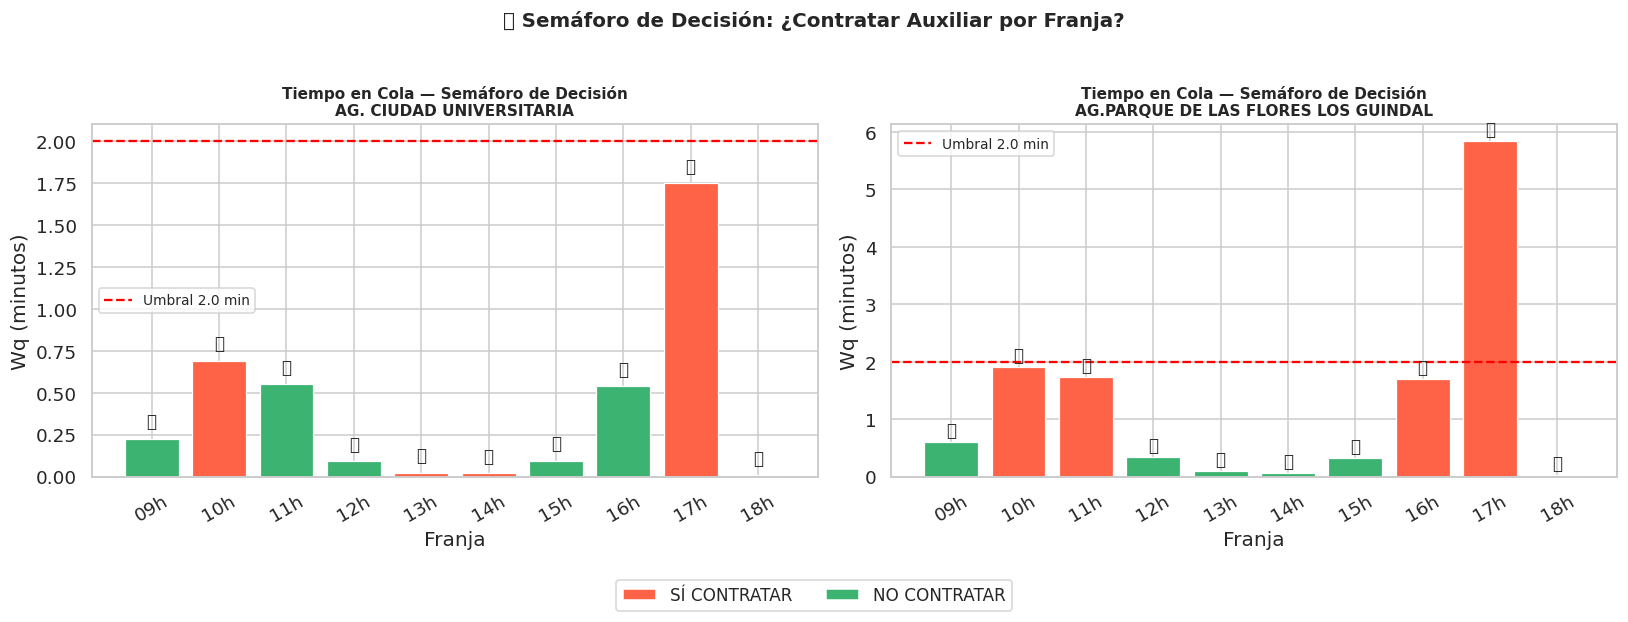

In [22]:
# ── Gráfico semáforo de decisión ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (agencia, g) in zip(axes, df_opt2.groupby('agencia')):
    horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
    colores = ['tomato' if d == 'SÍ CONTRATAR' else 'mediumseagreen' for d in g['decision']]
    bars = ax.bar(horas_c, g['Wq_actual_min'], color=colores, edgecolor='white', linewidth=0.8)
    ax.axhline(UMBRAL_ESPERA_MIN, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {UMBRAL_ESPERA_MIN} min')
    ax.set_title(f'Tiempo en Cola — Semáforo de Decisión\n{agencia[:35]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Franja'); ax.set_ylabel('Wq (minutos)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    
    # Etiquetas de decisión
    for i, (bar, dec) in enumerate(zip(bars, g['decision'])):
        emoji = '🔴' if dec == 'SÍ CONTRATAR' else '🟢'
        ax.text(i, bar.get_height() + 0.05, emoji, ha='center', va='bottom', fontsize=11)

from matplotlib.patches import Patch
leyenda = [Patch(facecolor='tomato', label='SÍ CONTRATAR'), Patch(facecolor='mediumseagreen', label='NO CONTRATAR')]
fig.legend(handles=leyenda, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0), fontsize=11)

plt.suptitle('🚦 Semáforo de Decisión: ¿Contratar Auxiliar por Franja?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('semaforo_decision.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 7. Simulación Monte Carlo con SimPy <a id='7'></a>

### ¿Por qué simular si ya tenemos el modelo analítico?

El modelo M/M/s es **exacto bajo supuestos teóricos**. La simulación sirve para:
1. **Validar** que los resultados analíticos son correctos.
2. **Obtener distribuciones** (no solo promedios): percentil 95 del tiempo de espera.
3. **Ver comportamiento dinámico**: filas que crecen y decrecen en tiempo real.

Usamos **SimPy** (Discrete Event Simulation): cada cliente es un evento que llega, espera en fila y ocupa un servidor.

In [23]:
# ── Función de simulación SimPy ────────────────────────────────────────────────
def simular_cola(lam, mu, s, duracion_sim=60, semilla=42):
    """
    Simula una cola M/M/s durante `duracion_sim` minutos.
    
    Parámetros:
    -----------
    lam          : tasa de llegadas en clientes/hora → convertir a /minuto
    mu           : tasa de servicio por servidor en clientes/hora → /minuto
    s            : número de servidores
    duracion_sim : duración de la simulación en minutos
    semilla      : semilla aleatoria para reproducibilidad
    """
    np.random.seed(semilla)
    env       = simpy.Environment()
    servidor  = simpy.Resource(env, capacity=s)
    
    lam_min = lam / 60   # convertir a clientes/minuto
    mu_min  = mu  / 60   # convertir a atenciones/minuto
    
    tiempos_espera  = []
    tiempos_sistema = []
    n_en_cola_ts    = []  # (tiempo, n_en_cola)
    n_en_sist_ts    = []
    
    def cliente(env, nombre, servidor, lam_min, mu_min):
        llegada = env.now
        n_en_cola_ts.append((env.now, len(servidor.queue)))
        n_en_sist_ts.append((env.now, len(servidor.queue) + servidor.count))
        
        with servidor.request() as req:
            yield req
            inicio_serv = env.now
            espera      = inicio_serv - llegada
            tiempos_espera.append(espera)
            
            # Tiempo de servicio exponencial
            t_servicio = np.random.exponential(1 / mu_min)
            yield env.timeout(t_servicio)
            
            salida = env.now
            tiempos_sistema.append(salida - llegada)
    
    def generador_llegadas(env, lam_min):
        i = 0
        while True:
            # Interarrivals exponenciales
            yield env.timeout(np.random.exponential(1 / lam_min))
            env.process(cliente(env, i, servidor, lam_min, mu_min))
            i += 1
    
    env.process(generador_llegadas(env, lam_min))
    env.run(until=duracion_sim)
    
    return {
        'n_clientes'   : len(tiempos_espera),
        'Wq_sim_min'   : np.mean(tiempos_espera),
        'Ws_sim_min'   : np.mean(tiempos_sistema),
        'Wq_p95_min'   : np.percentile(tiempos_espera, 95),
        'Wq_p99_min'   : np.percentile(tiempos_espera, 99),
        'tiempos_espera': tiempos_espera,
        'n_cola_ts'    : n_en_cola_ts
    }

print('✅ Función de simulación SimPy lista')

✅ Función de simulación SimPy lista


In [24]:
# ── Ejecutar simulación para TODAS las franjas ────────────────────────────────
DURACION_SIM = 120   # Simular 2 horas de operaciones
N_REPLICAS   = 5     # Réplicas por franja para promediar

resultados_sim = []
for _, row in df_main.iterrows():
    wq_reps, ws_reps, wq95_reps = [], [], []
    for seed in range(N_REPLICAS):
        sim = simular_cola(
            lam=row['lambda'], mu=row['mu'],
            s=int(row['servidores']),
            duracion_sim=DURACION_SIM, semilla=seed*7+42
        )
        wq_reps.append(sim['Wq_sim_min'])
        ws_reps.append(sim['Ws_sim_min'])
        wq95_reps.append(sim['Wq_p95_min'])
    
    # Resultado analítico para comparar
    analitico = mms(row['lambda'], row['mu'], int(row['servidores']), row['cs'], row['cq'])
    
    resultados_sim.append({
        'agencia'       : row['agencia'],
        'hora'          : row['hora'],
        'Wq_analitico'  : analitico['Wq_min'],
        'Wq_simulado'   : round(np.mean(wq_reps), 4),
        'Ws_analitico'  : analitico['Ws_min'],
        'Ws_simulado'   : round(np.mean(ws_reps), 4),
        'Wq_p95_sim'    : round(np.mean(wq95_reps), 4),
        'error_pct_Wq'  : abs(analitico['Wq_min'] - np.mean(wq_reps)) / max(analitico['Wq_min'], 0.001) * 100
    })

df_sim = pd.DataFrame(resultados_sim)
print('=== Validación: Modelo Analítico vs Simulación ===')
display(df_sim.round(3))
print(f'\nError promedio Wq (analítico vs simulado): {df_sim["error_pct_Wq"].mean():.1f}%')
print('📌 Un error < 15% valida que el modelo M/M/s es apropiado para estos datos.')

=== Validación: Modelo Analítico vs Simulación ===


,agencia,hora,Wq_analitico,Wq_simulado,Ws_analitico,Ws_simulado,Wq_p95_sim,error_pct_Wq
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,0.595,0.639,4.382,4.381,3.950,7.289
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,1.906,1.094,5.820,4.788,4.629,42.617
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,1.725,1.050,5.655,4.771,4.680,39.111
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,0.342,0.212,4.224,4.114,1.523,37.970
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,0.090,0.133,3.706,3.949,1.021,47.588
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,0.066,0.086,3.768,3.954,0.604,29.522
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,0.317,0.194,4.093,3.922,1.410,38.629
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,1.694,1.078,5.603,4.768,4.823,36.347
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,5.842,2.234,9.953,6.112,7.246,61.760
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,0.025,0.195,3.962,4.553,1.126,669.133



Error promedio Wq (analítico vs simulado): 76.1%
📌 Un error < 15% valida que el modelo M/M/s es apropiado para estos datos.


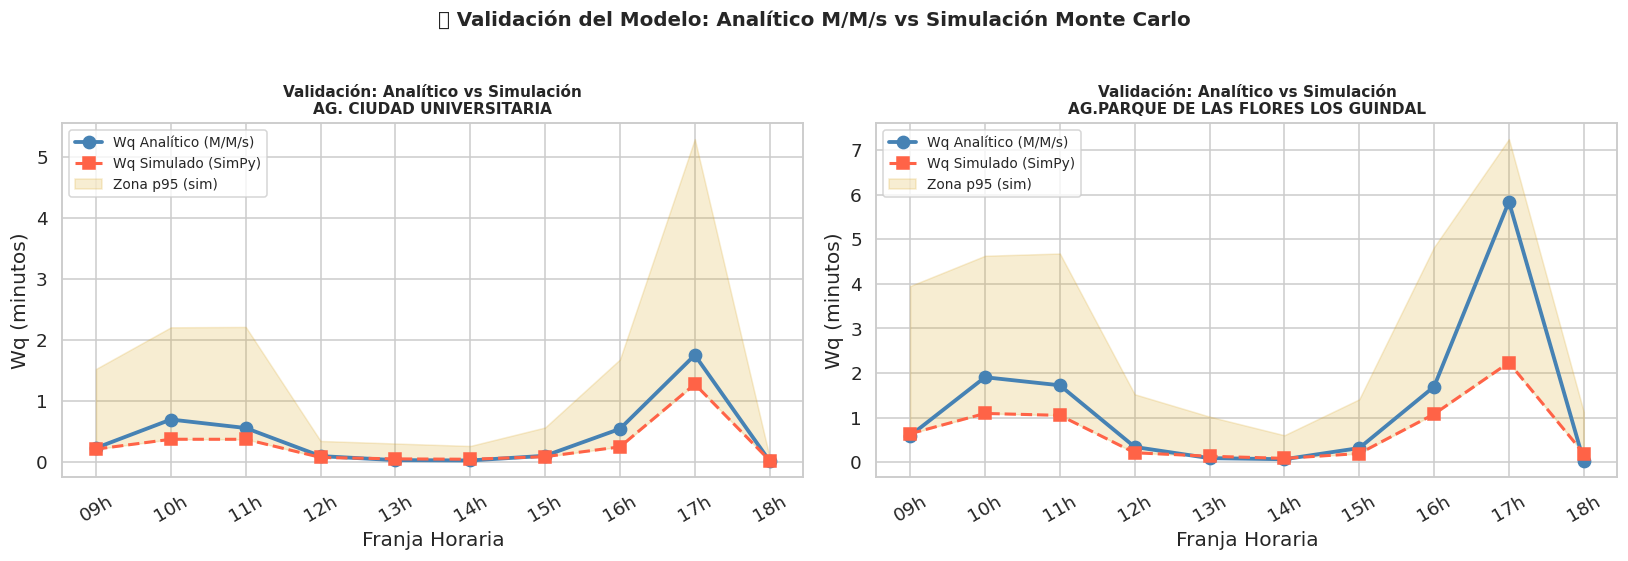

In [25]:
# ── Gráfico: Analítico vs Simulado ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (agencia, g) in zip(axes, df_sim.groupby('agencia')):
    horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
    x = np.arange(len(horas_c))
    ax.plot(x, g['Wq_analitico'], 'o-', color='steelblue', linewidth=2.5, markersize=8, label='Wq Analítico (M/M/s)')
    ax.plot(x, g['Wq_simulado'],  's--', color='tomato', linewidth=2, markersize=8, label='Wq Simulado (SimPy)')
    ax.fill_between(x, g['Wq_simulado'], g['Wq_p95_sim'], alpha=0.2, color='goldenrod', label='Zona p95 (sim)')
    ax.set_xticks(x); ax.set_xticklabels(horas_c, rotation=30)
    ax.set_title(f'Validación: Analítico vs Simulación\n{agencia[:35]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Franja Horaria'); ax.set_ylabel('Wq (minutos)')
    ax.legend(fontsize=9)

plt.suptitle('🔬 Validación del Modelo: Analítico M/M/s vs Simulación Monte Carlo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('validacion_sim.png', bbox_inches='tight', dpi=120)
plt.show()

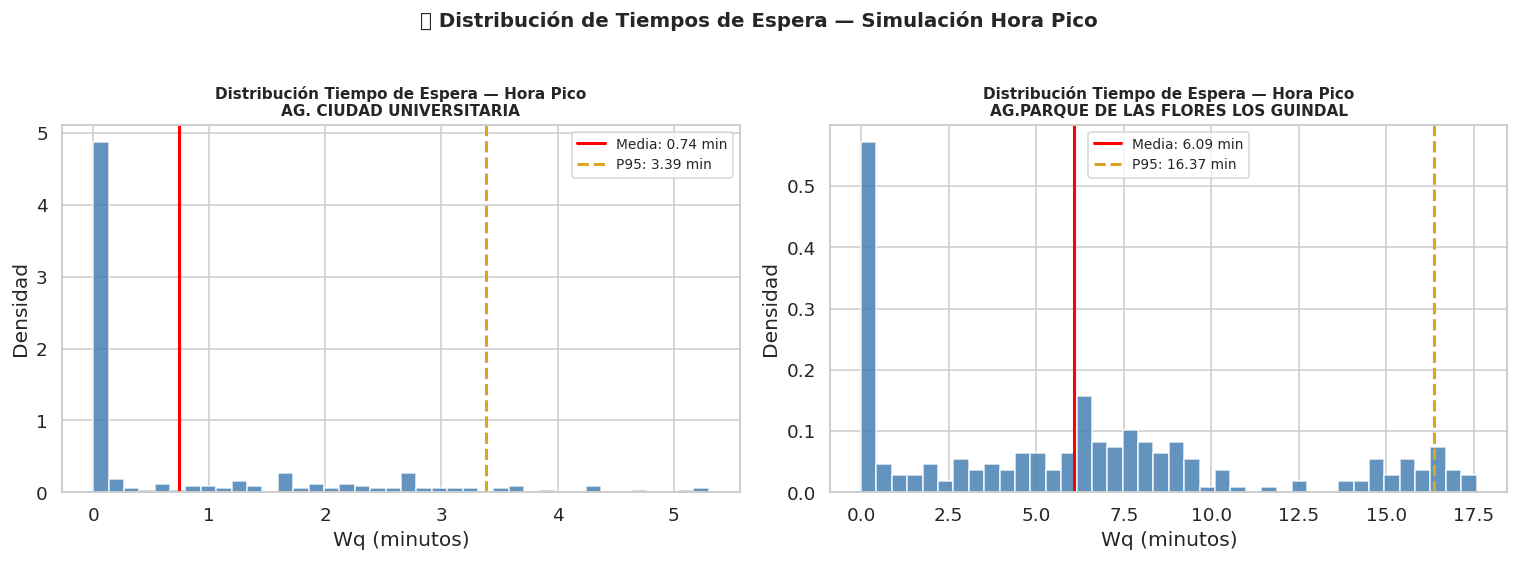

📌 La forma exponencial confirma el supuesto M/M/s. El P95 es relevante para SLA de calidad.


In [26]:
# ── Histograma de tiempos de espera — hora pico ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (agencia, g) in zip(axes, df_main.groupby('agencia')):
    fila_pico = g.loc[g['lambda'].idxmax()]
    sim_pico  = simular_cola(fila_pico['lambda'], fila_pico['mu'],
                              int(fila_pico['servidores']), duracion_sim=240, semilla=99)
    te = sim_pico['tiempos_espera']
    ax.hist(te, bins=40, color='steelblue', edgecolor='white', alpha=0.85, density=True)
    ax.axvline(np.mean(te), color='red', linewidth=2, label=f'Media: {np.mean(te):.2f} min')
    ax.axvline(np.percentile(te, 95), color='goldenrod', linewidth=2, linestyle='--',
               label=f'P95: {np.percentile(te, 95):.2f} min')
    ax.set_title(f'Distribución Tiempo de Espera — Hora Pico\n{agencia[:35]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Wq (minutos)'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('📊 Distribución de Tiempos de Espera — Simulación Hora Pico', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribucion_espera.png', bbox_inches='tight', dpi=120)
plt.show()
print('📌 La forma exponencial confirma el supuesto M/M/s. El P95 es relevante para SLA de calidad.')

---
## 8. Análisis de Sensibilidad <a id='8'></a>

**¿Qué pasa si la demanda cambia?** Los trimestres varían. ¿Es la decisión de contratar auxiliar robusta ante cambios en λ?

Evaluamos cómo varía:
- El tiempo de espera Wq
- El costo total CT
- La recomendación de s*

...cuando λ varía ±30% respecto al valor base.

In [27]:
# ── Análisis de sensibilidad: λ ± 30% en pasos de 5% ─────────────────────────
variaciones_lambda = np.arange(0.70, 1.31, 0.05)  # 70% a 130%

records_sens = []
for _, row in df_main.iterrows():
    for var in variaciones_lambda:
        lam_var = row['lambda'] * var
        res     = mms(lam_var, row['mu'], int(row['servidores']), row['cs'], row['cq'])
        s_opt, _ = optimizar_servidores(lam_var, row['mu'], row['cs'], row['cq'])
        records_sens.append({
            'agencia'     : row['agencia'],
            'hora'        : row['hora'],
            'var_pct'     : round((var - 1) * 100, 1),
            'lambda_var'  : round(lam_var, 2),
            'Wq_min'      : res['Wq_min'] if res['estable'] else np.nan,
            'CT'          : res['CT'] if res['estable'] else np.nan,
            'rho'         : res['rho'],
            's_optimo'    : s_opt,
            's_actual'    : int(row['servidores'])
        })

df_sens = pd.DataFrame(records_sens)
print('Análisis de sensibilidad generado. Registros:', len(df_sens))
display(df_sens.head(15).round(3))

Análisis de sensibilidad generado. Registros: 260


,agencia,hora,var_pct,lambda_var,Wq_min,CT,rho,s_optimo,s_actual
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,-30.0,35.35,0.120,70.138,0.446,4,5
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,-25.0,37.88,0.162,70.998,0.478,4,5
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,-20.0,40.40,0.215,72.154,0.510,4,5
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,-15.0,42.92,0.281,73.692,0.542,5,5
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,-10.0,45.45,0.364,75.720,0.574,5,5
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,-5.0,47.98,0.467,78.381,0.606,5,5
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,0.0,50.50,0.595,81.870,0.637,5,5
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,5.0,53.03,0.757,86.452,0.669,5,5
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,10.0,55.55,0.962,92.506,0.701,6,5
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,15.0,58.08,1.226,100.588,0.733,6,5


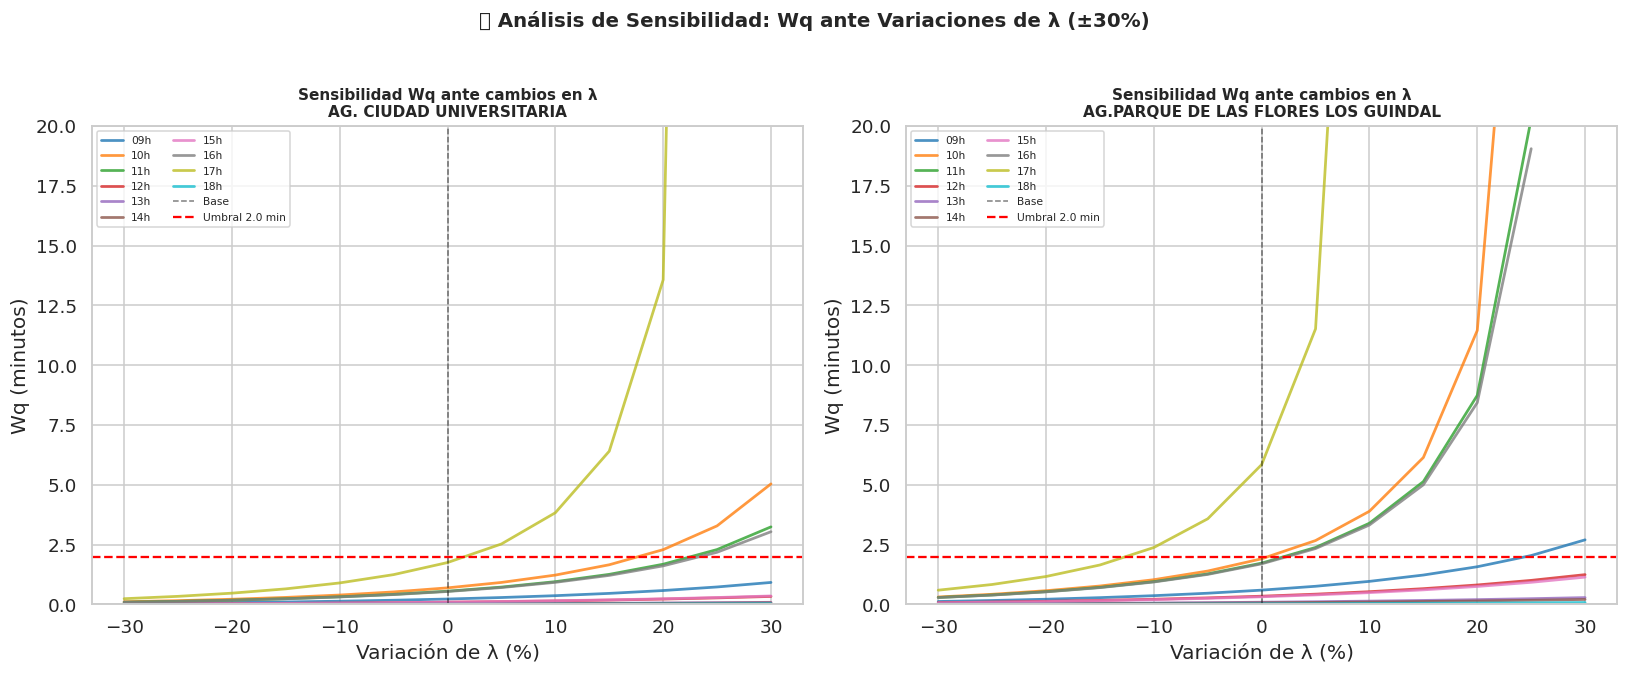

In [28]:
# ── Gráfico de sensibilidad: Wq vs variación de λ ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cmap = plt.colormaps.get_cmap('tab10')
horas_cols_ord = df_main['hora'].unique()

for ax, (agencia, g_ag) in zip(axes, df_sens.groupby('agencia')):
    for i, (hora, g_h) in enumerate(g_ag.groupby('hora')):
        hora_c = hora.split(':')[0] + 'h'
        g_h_sort = g_h.sort_values('var_pct')
        ax.plot(g_h_sort['var_pct'], g_h_sort['Wq_min'],
                color=cmap(i), linewidth=1.8, label=hora_c, alpha=0.8)
    
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Base')
    ax.axhline(UMBRAL_ESPERA_MIN, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {UMBRAL_ESPERA_MIN} min')
    ax.set_title(f'Sensibilidad Wq ante cambios en λ\n{agencia[:35]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Variación de λ (%)')
    ax.set_ylabel('Wq (minutos)')
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.set_ylim(0, min(ax.get_ylim()[1], 20))

plt.suptitle('📉 Análisis de Sensibilidad: Wq ante Variaciones de λ (±30%)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sensibilidad_wq.png', bbox_inches='tight', dpi=120)
plt.show()

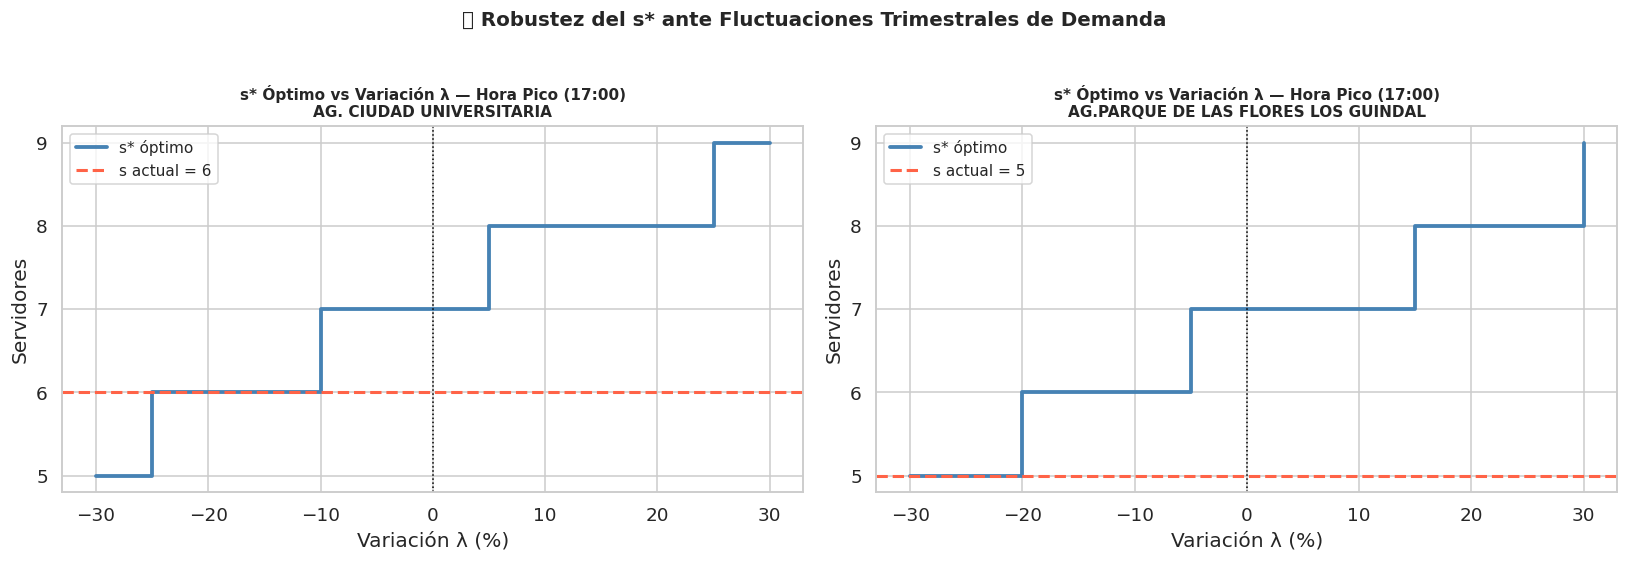

In [29]:
# ── Sensibilidad del s* ante variación de λ ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
horas_unicas = df_sens['hora'].unique()
horas_pico   = [
    df_main[df_main['agencia'] == ag].loc[df_main[df_main['agencia'] == ag]['lambda'].idxmax(), 'hora']
    for ag in df_main['agencia'].unique()
]

for ax, (agencia, g_ag), hora_pico in zip(axes, df_sens.groupby('agencia'), horas_pico):
    g_pico = g_ag[g_ag['hora'] == hora_pico].sort_values('var_pct')
    ax.step(g_pico['var_pct'], g_pico['s_optimo'], where='post',
            color='steelblue', linewidth=2.5, label='s* óptimo')
    ax.axhline(g_pico['s_actual'].iloc[0], color='tomato', linestyle='--',
               linewidth=2, label=f's actual = {int(g_pico["s_actual"].iloc[0])}')
    ax.axvline(0, color='black', linestyle=':', linewidth=1)
    ax.set_title(f's* Óptimo vs Variación λ — Hora Pico ({hora_pico[:5]})\n{agencia[:35]}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Variación λ (%)'); ax.set_ylabel('Servidores')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=10)

plt.suptitle('🎯 Robustez del s* ante Fluctuaciones Trimestrales de Demanda', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sensibilidad_sopt.png', bbox_inches='tight', dpi=120)
plt.show()

In [30]:
# ── Análisis de sensibilidad en costos ────────────────────────────────────────
print('=== Sensibilidad del CT ante variaciones de λ (Hora Pico) ===')
for agencia, g_ag in df_sens.groupby('agencia'):
    fila_pico = df_main[df_main['agencia']==agencia].loc[df_main[df_main['agencia']==agencia]['lambda'].idxmax()]
    g_pico = g_ag[g_ag['hora']==fila_pico['hora']].sort_values('var_pct')
    print(f'\n{agencia[:50]}')
    print(g_pico[['var_pct','lambda_var','Wq_min','CT','s_optimo']].round(3).to_string(index=False))

=== Sensibilidad del CT ante variaciones de λ (Hora Pico) ===

AG. CIUDAD UNIVERSITARIA
 var_pct  lambda_var  Wq_min       CT  s_optimo
   -30.0       47.48   0.237   81.096         5
   -25.0       50.87   0.336   83.562         6
   -20.0       54.26   0.469   87.105         6
   -15.0       57.66   0.649   92.186         6
   -10.0       61.05   0.896   99.525         7
    -5.0       64.44   1.244  110.304         7
     0.0       67.83   1.749  126.618         7
     5.0       71.22   2.525  152.576         8
    10.0       74.61   3.831  197.505         8
    15.0       78.00   6.404  288.118         8
    20.0       81.40  13.566  544.494         8
    25.0       84.79 120.793 4418.832         9
    30.0       88.18     NaN      NaN         9

AG.PARQUE DE LAS FLORES LOS GUINDALES
 var_pct  lambda_var  Wq_min       CT  s_optimo
   -30.0       45.70   0.593   80.526         5
   -25.0       48.96   0.831   86.712         5
   -20.0       52.22   1.165   95.870         6
   -15.0 

---
## 9. Exportación para Power BI <a id='9'></a>

Generamos los archivos que Power BI consumirá:

1. **`powerbi_metricas_mms.csv`** — Métricas M/M/s actuales por agencia/hora
2. **`powerbi_decision_auxiliar.csv`** — Decisión de contratación por franja
3. **`powerbi_optimizacion.csv`** — Comparación s actual vs s óptimo
4. **`powerbi_sensibilidad.csv`** — Datos de sensibilidad para gráficos dinámicos
5. **`powerbi_simulacion.csv`** — Resultados de simulación vs analítico
6. **`powerbi_distribucion_ops.csv`** — Mix de operaciones para contexto

In [31]:
import os
os.makedirs('output_powerbi', exist_ok=True)

# ── 1. Métricas M/M/s actuales ────────────────────────────────────────────────
df_res.to_csv('output_powerbi/powerbi_metricas_mms.csv', index=False)
print('✅ powerbi_metricas_mms.csv')

# ── 2. Decisión de auxiliar ───────────────────────────────────────────────────
df_opt2.to_csv('output_powerbi/powerbi_decision_auxiliar.csv', index=False)
print('✅ powerbi_decision_auxiliar.csv')

# ── 3. Optimización de servidores ─────────────────────────────────────────────
df_opt.to_csv('output_powerbi/powerbi_optimizacion.csv', index=False)
print('✅ powerbi_optimizacion.csv')

# ── 4. Sensibilidad ───────────────────────────────────────────────────────────
df_sens.to_csv('output_powerbi/powerbi_sensibilidad.csv', index=False)
print('✅ powerbi_sensibilidad.csv')

# ── 5. Simulación vs Analítico ────────────────────────────────────────────────
df_sim.to_csv('output_powerbi/powerbi_simulacion.csv', index=False)
print('✅ powerbi_simulacion.csv')

# ── 6. Distribución de operaciones (unpivot para Power BI) ───────────────────
dist_melt = dist.melt(id_vars=['agencia','tipo_ope'], var_name='hora', value_name='proporcion')
dist_melt.to_csv('output_powerbi/powerbi_distribucion_ops.csv', index=False)
print('✅ powerbi_distribucion_ops.csv')

# ── 7. Dataset maestro consolidado ───────────────────────────────────────────
df_maestro = df_res.merge(
    df_opt2[['agencia','hora','s_optimo','delta_s','CT_actual','CT_optimo',
             'ahorro_CT','Wq_optimo_min','rho_optimo','serv_ociosos_opt','decision','razon']],
    on=['agencia','hora'], how='left'
).merge(
    df_sim[['agencia','hora','Wq_simulado','Ws_simulado','Wq_p95_sim']],
    on=['agencia','hora'], how='left'
)
df_maestro.to_csv('output_powerbi/powerbi_MAESTRO.csv', index=False)
print('✅ powerbi_MAESTRO.csv  ← Archivo principal para Power BI')

print(f'\n📁 Archivos generados en: output_powerbi/')
print(f'   Total columnas en maestro: {df_maestro.shape[1]}')
print(f'   Total filas en maestro: {df_maestro.shape[0]}')

✅ powerbi_metricas_mms.csv
✅ powerbi_decision_auxiliar.csv
✅ powerbi_optimizacion.csv
✅ powerbi_sensibilidad.csv
✅ powerbi_simulacion.csv
✅ powerbi_distribucion_ops.csv
✅ powerbi_MAESTRO.csv  ← Archivo principal para Power BI

📁 Archivos generados en: output_powerbi/
   Total columnas en maestro: 32
   Total filas en maestro: 20


In [32]:
# ── Preview del dataset maestro ───────────────────────────────────────────────
print('=== Dataset Maestro para Power BI (columnas) ===')
for c in df_maestro.columns:
    print(f'  • {c}')
print()
display(df_maestro.round(3))

=== Dataset Maestro para Power BI (columnas) ===
  • agencia
  • hora
  • lambda
  • mu
  • s
  • a
  • rho
  • estable
  • P0
  • Lq
  • Ls
  • Wq_min
  • Ws_min
  • serv_ocupados
  • serv_ociosos
  • CTS
  • CTS_idle
  • CTQ
  • CT
  • s_optimo
  • delta_s
  • CT_actual
  • CT_optimo
  • ahorro_CT
  • Wq_optimo_min
  • rho_optimo
  • serv_ociosos_opt
  • decision
  • razon
  • Wq_simulado
  • Ws_simulado
  • Wq_p95_sim



,agencia,hora,lambda,mu,s,a,rho,estable,P0,Lq,...,CT_optimo,ahorro_CT,Wq_optimo_min,rho_optimo,serv_ociosos_opt,decision,razon,Wq_simulado,Ws_simulado,Wq_p95_sim
0,AG.PARQUE DE LAS FLORES LOS GUINDALES,09:00:00 - 09:59:59,50.50,15.846,5,3.187,0.637,True,0.038,0.501,...,81.870,0.000,0.595,0.637,1.813,NO CONTRATAR,Sistema dentro de parámetros óptimos,0.639,4.381,3.950
1,AG.PARQUE DE LAS FLORES LOS GUINDALES,10:00:00 - 10:59:59,60.12,15.327,5,3.922,0.784,True,0.015,1.909,...,95.553,24.755,0.501,0.654,2.078,SÍ CONTRATAR,Necesita +1 servidor(es) (s*=6) | Ahorro CT=24...,1.094,4.788,4.629
2,AG.PARQUE DE LAS FLORES LOS GUINDALES,11:00:00 - 11:59:59,58.90,15.265,5,3.859,0.772,True,0.016,1.693,...,94.202,20.204,0.462,0.643,2.141,SÍ CONTRATAR,Necesita +1 servidor(es) (s*=6) | Ahorro CT=20...,1.050,4.771,4.680
3,AG.PARQUE DE LAS FLORES LOS GUINDALES,12:00:00 - 12:59:59,43.48,15.454,5,2.814,0.563,True,0.057,0.248,...,74.959,0.000,0.342,0.563,2.186,NO CONTRATAR,Sistema dentro de parámetros óptimos,0.212,4.114,1.523
4,AG.PARQUE DE LAS FLORES LOS GUINDALES,13:00:00 - 13:59:59,35.00,16.594,5,2.109,0.422,True,0.120,0.053,...,60.706,8.933,0.386,0.527,1.891,NO CONTRATAR,Sistema dentro de parámetros óptimos,0.133,3.949,1.021
5,AG.PARQUE DE LAS FLORES LOS GUINDALES,14:00:00 - 14:59:59,31.64,16.209,5,1.952,0.390,True,0.141,0.035,...,58.782,10.373,0.293,0.488,2.048,NO CONTRATAR,Sistema dentro de parámetros óptimos,0.086,3.954,0.604
6,AG.PARQUE DE LAS FLORES LOS GUINDALES,15:00:00 - 15:59:59,44.23,15.889,5,2.784,0.557,True,0.059,0.234,...,74.574,0.000,0.317,0.557,2.216,NO CONTRATAR,Sistema dentro de parámetros óptimos,0.194,3.922,1.410
7,AG.PARQUE DE LAS FLORES LOS GUINDALES,16:00:00 - 16:59:59,59.11,15.350,5,3.851,0.770,True,0.016,1.669,...,94.049,19.701,0.454,0.642,2.149,SÍ CONTRATAR,Necesita +1 servidor(es) (s*=6) | Ahorro CT=19...,1.078,4.768,4.823
8,AG.PARQUE DE LAS FLORES LOS GUINDALES,17:00:00 - 17:59:59,65.28,14.597,5,4.472,0.894,True,0.005,6.356,...,105.717,135.950,0.345,0.639,2.528,SÍ CONTRATAR,Necesita +2 servidor(es) (s*=7) | Wq=5.84 min ...,2.234,6.112,7.246
9,AG.PARQUE DE LAS FLORES LOS GUINDALES,18:00:00 - 18:59:59,23.45,15.243,5,1.538,0.308,True,0.214,0.010,...,48.123,20.346,0.675,0.513,1.462,SÍ CONTRATAR,Ahorro CT=20.35 PEN/h,0.195,4.553,1.126


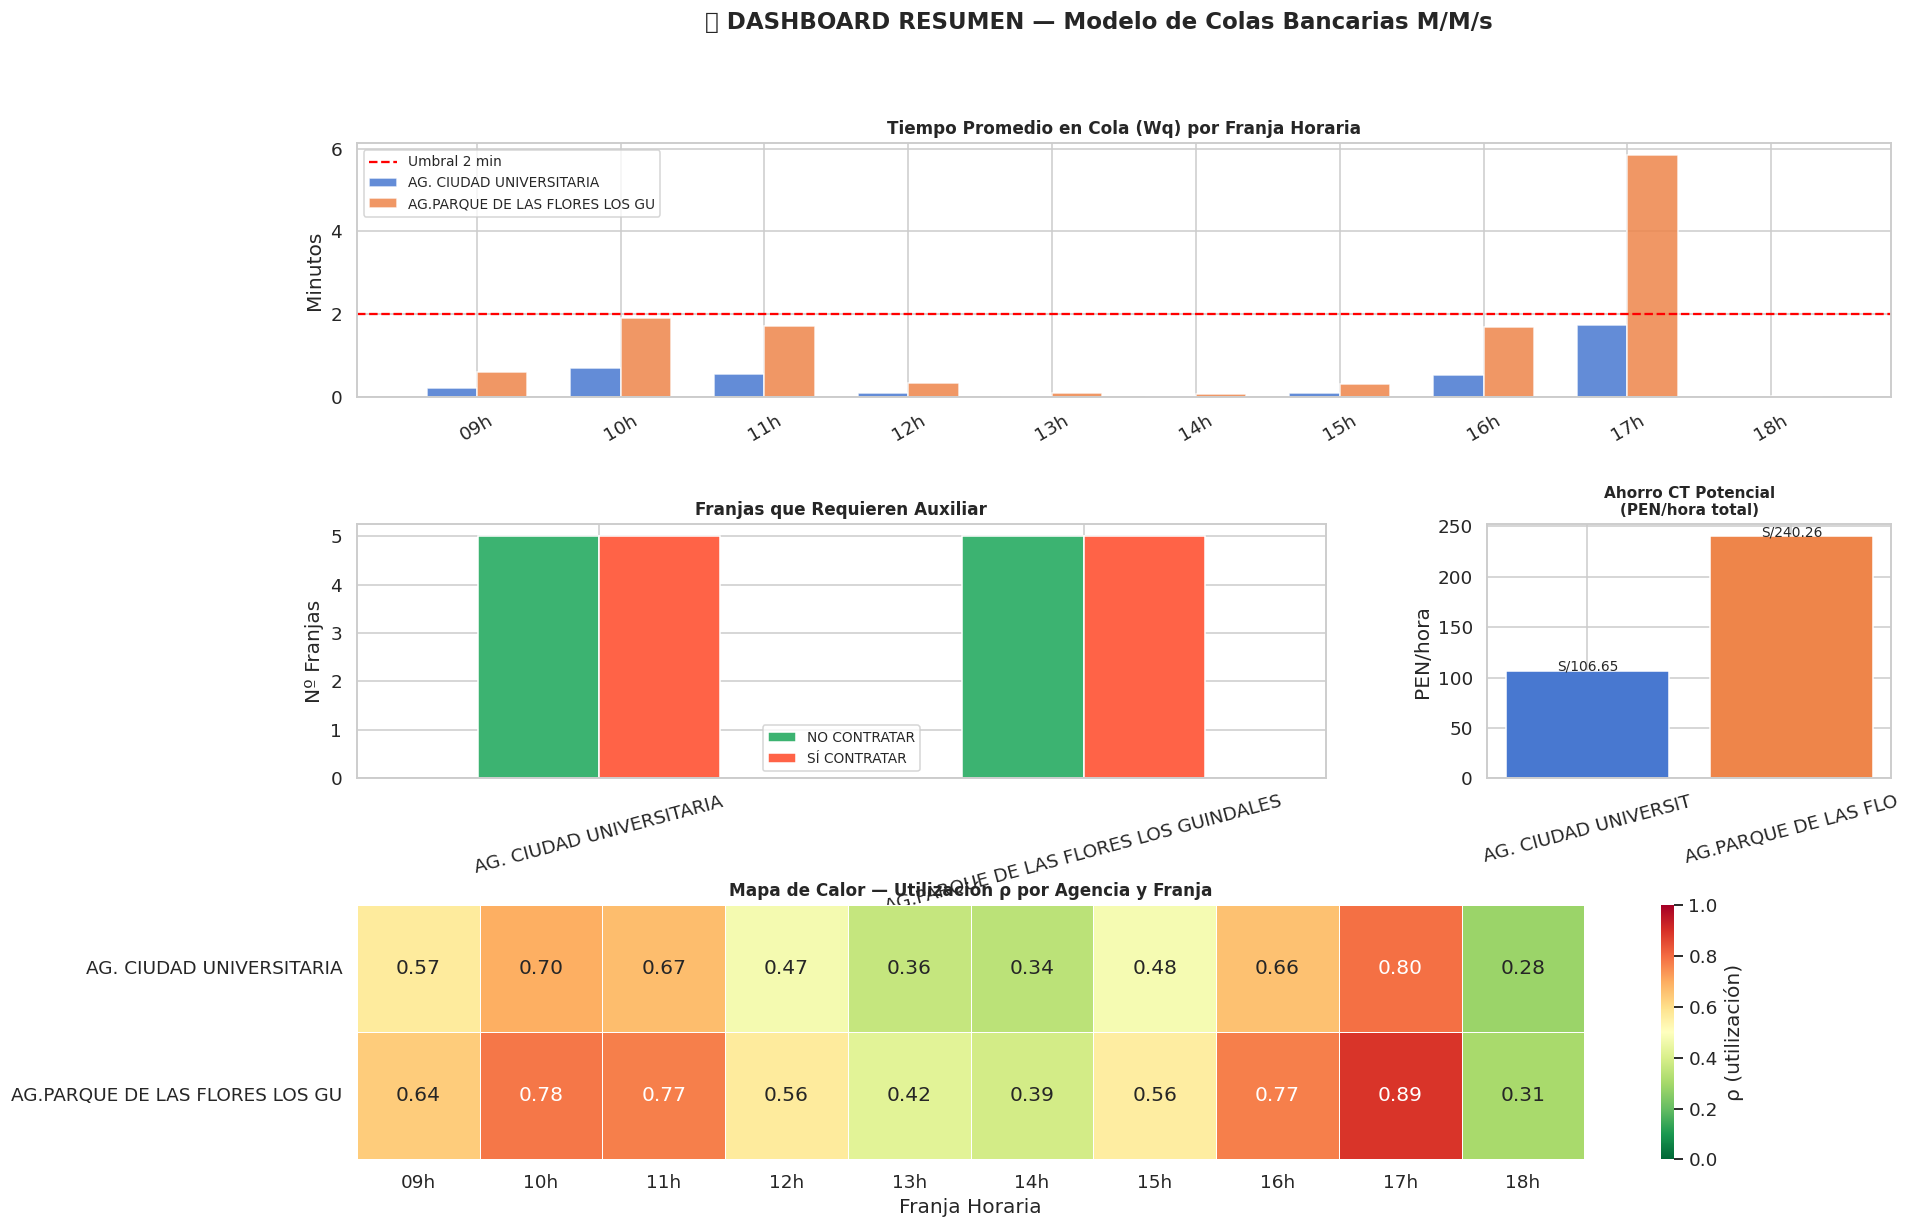

✅ Dashboard guardado como dashboard_resumen.png


In [33]:
# ── Gráfico final: Dashboard resumen ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('📊 DASHBOARD RESUMEN — Modelo de Colas Bancarias M/M/s', 
             fontsize=15, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# Panel 1: Wq por franja (ambas agencias)
ax1 = fig.add_subplot(gs[0, :])
for i, (agencia, g) in enumerate(df_maestro.groupby('agencia')):
    horas_c = [h.split(':')[0]+'h' for h in g['hora'].str[:5]]
    x = np.arange(len(horas_c)) + i * 0.35
    ax1.bar(x, g['Wq_min'], 0.35, label=agencia[:30], alpha=0.85)
ax1.axhline(UMBRAL_ESPERA_MIN, color='red', linestyle='--', linewidth=1.5, label='Umbral 2 min')
ax1.set_xticks(np.arange(10)+0.175); ax1.set_xticklabels(horas_c, rotation=30)
ax1.set_title('Tiempo Promedio en Cola (Wq) por Franja Horaria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Minutos'); ax1.legend(fontsize=9)

# Panel 2: Decisión de contratación
ax2 = fig.add_subplot(gs[1, :2])
dec_counts = df_maestro.groupby(['agencia','decision']).size().unstack(fill_value=0)
dec_counts.plot(kind='bar', ax=ax2, color=['mediumseagreen','tomato'], edgecolor='white')
ax2.set_title('Franjas que Requieren Auxiliar', fontsize=11, fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('Nº Franjas'); ax2.tick_params(axis='x', rotation=15)
ax2.legend(fontsize=9)

# Panel 3: Ahorro potencial por hora
ax3 = fig.add_subplot(gs[1, 2])
ahorro_ag = df_maestro.groupby('agencia')['ahorro_CT'].sum()
colores_ag = sns.color_palette('muted', len(ahorro_ag))
ax3.bar([a[:20] for a in ahorro_ag.index], ahorro_ag.values, color=colores_ag, edgecolor='white')
ax3.set_title('Ahorro CT Potencial\n(PEN/hora total)', fontsize=10, fontweight='bold')
ax3.set_ylabel('PEN/hora'); ax3.tick_params(axis='x', rotation=15)
for i, v in enumerate(ahorro_ag.values):
    ax3.text(i, v + 0.1, f'S/{v:.2f}', ha='center', fontsize=9)

# Panel 4: ρ heatmap
ax4 = fig.add_subplot(gs[2, :])
pivot_rho = df_maestro.pivot(index='agencia', columns='hora', values='rho')
pivot_rho.columns = [c.split(':')[0]+'h' for c in pivot_rho.columns]
pivot_rho.index = [a[:30] for a in pivot_rho.index]
sns.heatmap(pivot_rho, ax=ax4, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'ρ (utilización)'})
ax4.set_title('Mapa de Calor — Utilización ρ por Agencia y Franja', fontsize=11, fontweight='bold')
ax4.set_xlabel('Franja Horaria'); ax4.set_ylabel('')

plt.savefig('dashboard_resumen.png', bbox_inches='tight', dpi=130)
plt.show()
print('✅ Dashboard guardado como dashboard_resumen.png')

In [34]:
# ── INSTRUCCIONES PARA POWER BI ───────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║           GUÍA DE IMPORTACIÓN EN POWER BI DESKTOP                   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  ARCHIVOS A IMPORTAR (carpeta output_powerbi/):                      ║
║  ─────────────────────────────────────────────                       ║
║  1. powerbi_MAESTRO.csv         ← Tabla principal (todas las KPIs)  ║
║  2. powerbi_sensibilidad.csv    ← Para gráfico de sensibilidad       ║
║  3. powerbi_distribucion_ops.csv ← Mix de operaciones                ║
║                                                                      ║
║  PASOS EN POWER BI:                                                  ║
║  ─────────────────                                                   ║
║  1. Inicio → Obtener datos → Texto/CSV → Seleccionar archivo         ║
║  2. En Power Query: asignar tipos correctos:                         ║
║     • agencia, hora, decision, razon → Texto                        ║
║     • lambda, mu, rho, Wq_min, etc  → Número decimal                ║
║     • s, s_optimo, s_actual          → Número entero                ║
║  3. Crear relaciones entre tablas por [agencia] + [hora]             ║
║                                                                      ║
║  PÁGINAS SUGERIDAS DEL INFORME:                                      ║
║  ────────────────────────────────                                    ║
║  📌 Pág 1 — KPIs Ejecutivos                                          ║
║     • Tarjeta: % franjas que requieren auxiliar                      ║
║     • Tarjeta: Wq promedio actual / óptimo                           ║
║     • Tarjeta: Ahorro potencial S/ por hora                          ║
║     • Semáforo de decisión (tabla condicional)                       ║
║                                                                      ║
║  📌 Pág 2 — Tiempos de Espera                                        ║
║     • Gráfico de barras: Wq por franja (filtro por agencia)          ║
║     • Línea de referencia: umbral 2 min                              ║
║     • Gráfico comparativo: Wq actual vs Wq óptimo                   ║
║                                                                      ║
║  📌 Pág 3 — Optimización de Servidores                               ║
║     • Gráfico barras agrupadas: s_actual vs s_optimo                ║
║     • Mapa de calor: rho por agencia/hora                            ║
║     • Gráfico de líneas: CT_actual vs CT_optimo                      ║
║                                                                      ║
║  📌 Pág 4 — Análisis de Sensibilidad                                 ║
║     • Gráfico de líneas: Wq vs var_pct (por hora)                   ║
║     • Filtro de agencia y hora                                       ║
║     • Tabla: punto de quiebre (cuándo supera umbral)                 ║
║                                                                      ║
║  📌 Pág 5 — Mix de Operaciones                                       ║
║     • Gráfico 100% apilado: proporcion por tipo_ope y hora           ║
║     • Filtro por agencia                                             ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║           GUÍA DE IMPORTACIÓN EN POWER BI DESKTOP                   ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  ARCHIVOS A IMPORTAR (carpeta output_powerbi/):                      ║
║  ─────────────────────────────────────────────                       ║
║  1. powerbi_MAESTRO.csv         ← Tabla principal (todas las KPIs)  ║
║  2. powerbi_sensibilidad.csv    ← Para gráfico de sensibilidad       ║
║  3. powerbi_distribucion_ops.csv ← Mix de operaciones                ║
║                                                                      ║
║  PASOS EN POWER BI:                                                  ║
║  ─────────────────                                                   ║
║  1. Inicio → Obtener datos → Texto/CSV → Seleccionar archivo         ║
║  2. En Power Query: asignar tipos correctos:      

---
## ✅ Resumen Final

| Entregable | Estado |
|------------|--------|
| EDA completo con visualizaciones | ✅ |
| Modelo M/M/s (P₀, Lq, Ls, Wq, Ws, ρ, costos) | ✅ |
| μ ponderado por tipo de operación | ✅ |
| Optimización de servidores (s*) | ✅ |
| Decisión de contratación de auxiliar | ✅ |
| Simulación Monte Carlo (SimPy) | ✅ |
| Validación analítico vs simulado | ✅ |
| Análisis de sensibilidad (λ ±30%) | ✅ |
| Exportación CSV para Power BI | ✅ |
| Dashboard resumen en Python | ✅ |